In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
 mainfolder = '/content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/'

In [ ]:
# plt.figure(figsize=(6,5))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

import os
import joblib  # to save the scaler

from numba import njit # for the LQ mass reconstruction

from scipy.optimize import fsolve, minimize
from scipy import stats
from scipy.stats import poisson
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import wasserstein_distance
from scipy.stats import chisquare
from scipy.interpolate import interp1d

import math
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.metrics import roc_curve, roc_auc_score, auc, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor, XGBClassifier
import xgboost as xgb

# LOAD DATA

## Background

In [ ]:
CHs_selected = ["tt", "singletP1", "singletP2", "Wbbjets", "ttW", "ttZ", "ttH"]


df_B_all = {}
X_B_all = {}


output_folder = mainfolder + "../DATA/backgrounds/data_df/"

for CH_sel in CHs_selected:
    # Read the file
    if CH_sel == 'singletP2':
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-singlet-comp/df_' + CH_sel + ".csv"
    else:
        filename = mainfolder + '../DATA-wjets/backgrounds/dats-' + CH_sel + '/df_' + CH_sel + ".csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_B_all[CH_sel] = df_temp
    X_B_all[CH_sel] = df_temp[feats_label].values

    # Print
    print(f"X_{CH_sel}.shape: {X_B_all[CH_sel].shape}")

X_tt.shape: (826022, 53)
X_singletP1.shape: (179677, 53)
X_singletP2.shape: (94219, 53)
X_Wbbjets.shape: (162448, 53)
X_ttW.shape: (141919, 53)
X_ttZ.shape: (16178, 53)
X_ttH.shape: (12068, 53)


## Signal SLQ

In [ ]:
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2200]
masses_SLQ = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]


df_SLQ_all = {}
X_SLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_SLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-SLQ-' + str(mass_sel) + 'GeV/df_SLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_SLQ_all[mass_sel] = df_temp
    X_SLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_SLQ_{mass_sel}GeV.shape: {X_SLQ_all[mass_sel].shape}")

X_SLQ_1000GeV.shape: (267452, 53)
X_SLQ_1100GeV.shape: (271062, 53)
X_SLQ_1200GeV.shape: (534247, 53)
X_SLQ_1300GeV.shape: (196510, 53)
X_SLQ_1400GeV.shape: (506381, 53)
X_SLQ_1500GeV.shape: (185940, 53)
X_SLQ_1600GeV.shape: (481827, 53)
X_SLQ_1700GeV.shape: (173573, 53)
X_SLQ_1800GeV.shape: (301687, 53)
X_SLQ_1900GeV.shape: (64690, 53)


## Signal VLQ

In [ ]:
masses_VLQ = [1200, 1500, 1400, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
masses_VLQ = [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

df_VLQ_all = {}
X_VLQ_all = {}


output_folder = mainfolder + "../DATA/signal/data_df/"

for mass_sel in masses_VLQ:
    # Read the file
    filename = mainfolder + '../DATA-wjets/signals/dats-VLQ-' + str(mass_sel) + 'GeV/df_VLQ_' + str(mass_sel) + "GeV.csv"

    df_temp = pd.read_csv(filename)

    # get the features
    feats_label = [c for c in df_temp.columns]

    # Save in the dictionary
    df_VLQ_all[mass_sel] = df_temp
    X_VLQ_all[mass_sel] = df_temp[feats_label].values

    # Print
    print(f"X_VLQ_{mass_sel}GeV.shape: {X_VLQ_all[mass_sel].shape}")

X_VLQ_1400GeV.shape: (139696, 53)
X_VLQ_1500GeV.shape: (293700, 53)
X_VLQ_1600GeV.shape: (134774, 53)
X_VLQ_1700GeV.shape: (192819, 53)
X_VLQ_1800GeV.shape: (127670, 53)
X_VLQ_1900GeV.shape: (75898, 53)
X_VLQ_2000GeV.shape: (184097, 53)
X_VLQ_2100GeV.shape: (72762, 53)
X_VLQ_2200GeV.shape: (232166, 53)
X_VLQ_2300GeV.shape: (64705, 53)


# Cross Section

In [ ]:
Lum = 3000

In [ ]:
# -------------------------
# cross sections
# -------------------------
k_LQ = 1.8877462860822058

xsec_file_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV.txt'

xsec_data_14TeV = np.loadtxt(xsec_file_14TeV, comments='#')

# columns: 0=mass, 1=SLQ, 2=VLQ
masses_14TeV = xsec_data_14TeV[:,0].astype(int)
fidxsec_SLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,1]*k_LQ))
fidxsec_VLQ_14TeV = dict(zip(masses_14TeV, xsec_data_14TeV[:,2]*k_LQ))


masses_SLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]
masses_VLQ_14TeV = [1200, 1400, 1600, 1800, 2000, 2200]

fidxsec_SLQ_non0_14TeV = [fidxsec_SLQ_14TeV[ii] for ii in masses_SLQ_14TeV]
fidxsec_VLQ_non0_14TeV = [fidxsec_VLQ_14TeV[ii] for ii in masses_VLQ_14TeV]


#  interpolate
f_xsec_SLQ_log_14TeV = interp1d(masses_SLQ_14TeV, np.log10(fidxsec_SLQ_non0_14TeV), kind='linear', fill_value="extrapolate")
f_xsec_VLQ_log_14TeV = interp1d(masses_VLQ_14TeV, np.log10(fidxsec_VLQ_non0_14TeV), kind='linear', fill_value="extrapolate")



# -------------------------
# cross sections
# -------------------------
xsec_file_betas_14TeV = mainfolder + '../DATA-wjets/signals/LQs-xsec-14TeV-betas.txt'

xsec_data_betas_14TeV = np.loadtxt(xsec_file_betas_14TeV, comments='#')

# columns: 0=beta, 1,...=SLQ, -1=ratio=fid_xsec(beta)/fid_xsec(beta=0.5)
betas = xsec_data_betas_14TeV[:,0]
ratio_mean_14TeV = xsec_data_betas_14TeV[:,-1]

#  interpolate
f_ratio_SLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")
f_ratio_VLQ_log_14TeV = interp1d(betas, ratio_mean_14TeV, kind='linear', fill_value="extrapolate")



# FINAL FUNCTIONS
def fid_xsec_SLQ_14TeV(mass, beta):
    return 10**f_xsec_SLQ_log_14TeV(mass) * f_ratio_SLQ_log_14TeV(beta)

def fid_xsec_VLQ_14TeV(mass, beta):
    return 10**f_xsec_VLQ_log_14TeV(mass) * f_ratio_VLQ_log_14TeV(beta)

In [ ]:
masses = [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

beta = 0.5

fidxsec_SLQ = dict(zip(masses, fid_xsec_SLQ_14TeV(masses, beta)))
fidxsec_VLQ = dict(zip(masses, fid_xsec_VLQ_14TeV(masses, beta)))


print('masses: ', masses)
print(fidxsec_SLQ[1200], '[fb]')
print(fidxsec_VLQ[1600], '[fb]')

masses:  [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
0.2474345231655215 [fb]
0.26523144909845914 [fb]


In [ ]:
# -----------------------------------
# LQs number and fid cross sections
# -----------------------------------

for m_it in masses_SLQ:
    print(f"# eventos SLQ {m_it} GeV:", len(X_SLQ_all[m_it]), "  fid_xsec = ", fidxsec_SLQ[m_it], "[fb]")

print(" ")
for m_it in masses_VLQ:
    print(f"# eventos VLQ {m_it} GeV:", len(X_VLQ_all[m_it]), "  fid_xsec = ", fidxsec_VLQ[m_it], "[fb]")

# eventos SLQ 1000 GeV: 267452   fid_xsec =  0.7748869590226768 [fb]
# eventos SLQ 1100 GeV: 271062   fid_xsec =  0.4378741659574781 [fb]
# eventos SLQ 1200 GeV: 534247   fid_xsec =  0.2474345231655215 [fb]
# eventos SLQ 1300 GeV: 196510   fid_xsec =  0.13982063344676618 [fb]
# eventos SLQ 1400 GeV: 506381   fid_xsec =  0.07901003177465696 [fb]
# eventos SLQ 1500 GeV: 185940   fid_xsec =  0.04581708431512623 [fb]
# eventos SLQ 1600 GeV: 481827   fid_xsec =  0.02656884408205899 [fb]
# eventos SLQ 1700 GeV: 173573   fid_xsec =  0.015388910834251649 [fb]
# eventos SLQ 1800 GeV: 301687   fid_xsec =  0.00891339404654277 [fb]
# eventos SLQ 1900 GeV: 64690   fid_xsec =  0.005260680024994185 [fb]
 
# eventos VLQ 1400 GeV: 139696   fid_xsec =  0.7980588250285466 [fb]
# eventos VLQ 1500 GeV: 293700   fid_xsec =  0.46007640520693416 [fb]
# eventos VLQ 1600 GeV: 134774   fid_xsec =  0.26523144909845914 [fb]
# eventos VLQ 1700 GeV: 192819   fid_xsec =  0.15538479377277226 [fb]
# eventos VLQ 1800 Ge

In [ ]:
# FOR 14 TeV

k_fakett = 1.1053030485310749
crossfid_fakett = 0.244
k_tt = 1.2593273872014419
crossfid_tt = (7.74198*k_tt) + (crossfid_fakett * k_fakett)


fidxsec_SM = {'tt': crossfid_tt,
              'singletP1': 0.632632 * 3.440676833094312,
              'singletP2': 0.3182704 * 3.440676833094312,
              'Wbbjets': 1.6542420183645095 * 0.9781509289273502,
              'ttW': 0.03683196 * 3.056401327463198,
              'ttZ': 0.0715444 * 3.056401327463198,
              'ttH': 0.03630132 * 2.2127445612386474
              }

for ch_it in fidxsec_SM:
    print(f"# eventos {ch_it}:", len(X_B_all[ch_it]), "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]")

# eventos tt: 826022   fid_xsec =  10.019381389007401 [fb]
# eventos singletP1: 179677   fid_xsec =  2.1766822662741205 [fb]
# eventos singletP2: 94219   fid_xsec =  1.09506559193966 [fb]
# eventos Wbbjets: 162448   fid_xsec =  1.6180983669338997 [fb]
# eventos ttW: 141919   fid_xsec =  0.1125732514370714 [fb]
# eventos ttZ: 16178   fid_xsec =  0.218668399132558 [fb]
# eventos ttH: 12068   fid_xsec =  0.08032554839578374 [fb]


In [ ]:
# MAX SM dataset
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])


weigth_gen_SM = {}

for ch_it in fidxsec_SM:

    print(f"fraction of {ch_it}:", fidxsec_SM[ch_it] / totalcrossSM )

    weigth_gen_SM[ch_it] = len(X_B_all[ch_it]) / (fidxsec_SM[ch_it] / totalcrossSM)

print('\nchannel limiting the SM background: ', min(weigth_gen_SM, key=weigth_gen_SM.get) , '\n')


max_evs_SM = {}

for ch_it in fidxsec_SM:
    max_evs_SM[ch_it] = round( min(weigth_gen_SM.values()) * (fidxsec_SM[ch_it] / totalcrossSM) )
    print(f"# eventos {ch_it} (max):", max_evs_SM[ch_it])

max_SM_dataset = sum(max_evs_SM.values())
print('\nmax SM dataset length: ', max_SM_dataset )

fraction of tt: 0.6539726894865112
fraction of singletP1: 0.14207371698562551
fraction of singletP2: 0.07147576906400852
fraction of Wbbjets: 0.10561451848099845
fraction of ttW: 0.0073477422555561795
fraction of ttZ: 0.014272653723245071
fraction of ttH: 0.005242910004055022

channel limiting the SM background:  ttZ 

# eventos tt (max): 741276
# eventos singletP1 (max): 161040
# eventos singletP2 (max): 81018
# eventos Wbbjets (max): 119714
# eventos ttW (max): 8329
# eventos ttZ (max): 16178
# eventos ttH (max): 5943

max SM dataset length:  1133498


## Number of events to get a balanced dataset

In [ ]:
# -------------------------
# Step 1: minimim number of events in LQs (selected mass)
# -------------------------

num_data_SLQ = [len(X_SLQ_all[m_it]) for m_it in masses_SLQ]

num_data_VLQ = [len(X_VLQ_all[m_it]) for m_it in masses_VLQ]


max_SM_dataset = min(1000000, max_SM_dataset)

num_data_NP = min(int(max_SM_dataset / (len(masses_SLQ) + len(masses_VLQ))) , min(num_data_SLQ + num_data_VLQ) )

print('SIGNAL: # events per-class chosen =', num_data_NP)



# -------------------------
# Step 2: background total fid_xsec
# -------------------------
totalcrossSM = sum([fidxsec_SM[ch_it] for ch_it in fidxsec_SM])



# -------------------------
# Step 3: number of events per chanel, proportional to xsec
# -------------------------
num_data_SM_dict = {}
for ch_it in fidxsec_SM:
    if ch_it == 'tt':
        # set at the end to have exactly the same # events (otherwise can be a difference of 1 due to rounding)
        continue
    fraction = fidxsec_SM[ch_it]/totalcrossSM
    num_data_SM_dict[ch_it] = round(num_data_NP * fraction * (len(masses_SLQ) + len(masses_VLQ)) )

# Set tt such that the total matches num_data_NP
num_data_SM_dict['tt'] = num_data_NP * (len(masses_SLQ) + len(masses_VLQ)) - sum([v for k,v in num_data_SM_dict.items() if k != 'tt'])



print('\nBACKGROUND events chosen (weighted by xsec):')
for ch_it in fidxsec_SM:
    print(f'# {ch_it}: {num_data_SM_dict[ch_it]}')
print('# total B events chosen: ', sum(num_data_SM_dict.values()))

SIGNAL: # events per-class chosen = 50000

BACKGROUND events chosen (weighted by xsec):
# tt: 653971
# singletP1: 142074
# singletP2: 71476
# Wbbjets: 105615
# ttW: 7348
# ttZ: 14273
# ttH: 5243
# total B events chosen:  1000000


In [ ]:
# keep just the events needed

for m_it in masses_SLQ:
    X_SLQ_all[m_it] = X_SLQ_all[m_it][:num_data_NP]
    df_SLQ_all[m_it] = df_SLQ_all[m_it][:num_data_NP]

print(" ")
for m_it in masses_VLQ:
    X_VLQ_all[m_it] = X_VLQ_all[m_it][:num_data_NP]
    df_VLQ_all[m_it] = df_VLQ_all[m_it][:num_data_NP]

print("")
for ch_it in fidxsec_SM:
    X_B_all[ch_it] = X_B_all[ch_it][:num_data_SM_dict[ch_it]]
    df_B_all[ch_it] = df_B_all[ch_it][:num_data_SM_dict[ch_it]]

In [ ]:
B_expected = round(Lum * totalcrossSM)    # luminosity * cross * aceptance
print('B_expected: ', B_expected)

for ch_it in fidxsec_SM:
    print(f" channel {ch_it}:", "  fid_xsec = ", fidxsec_SM[ch_it], "[fb]", " B_exp_ch: ", round(Lum * fidxsec_SM[ch_it]) )


S_expected_SLQ = []

for m_it in masses_SLQ:
    S_expected_SLQ.append( round(Lum * fidxsec_SLQ[m_it]) )

print('\nmasses:           ', masses_SLQ)
print('S_expected (SLQ): ', S_expected_SLQ)    # luminosity * cross * aceptance



S_expected_VLQ = []

for m_it in masses_VLQ:
    S_expected_VLQ.append( round(Lum * fidxsec_VLQ[m_it]) )

print('\nmasses:           ', masses_VLQ)
print('S_expected (VLQ): ', S_expected_VLQ)    # luminosity * cross * aceptance

B_expected:  45962
 channel tt:   fid_xsec =  10.019381389007401 [fb]  B_exp_ch:  30058
 channel singletP1:   fid_xsec =  2.1766822662741205 [fb]  B_exp_ch:  6530
 channel singletP2:   fid_xsec =  1.09506559193966 [fb]  B_exp_ch:  3285
 channel Wbbjets:   fid_xsec =  1.6180983669338997 [fb]  B_exp_ch:  4854
 channel ttW:   fid_xsec =  0.1125732514370714 [fb]  B_exp_ch:  338
 channel ttZ:   fid_xsec =  0.218668399132558 [fb]  B_exp_ch:  656
 channel ttH:   fid_xsec =  0.08032554839578374 [fb]  B_exp_ch:  241

masses:            [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_expected (SLQ):  [2325, 1314, 742, 419, 237, 137, 80, 46, 27, 16]

masses:            [1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_expected (VLQ):  [2394, 1380, 796, 466, 273, 163, 98, 59, 36, 22]


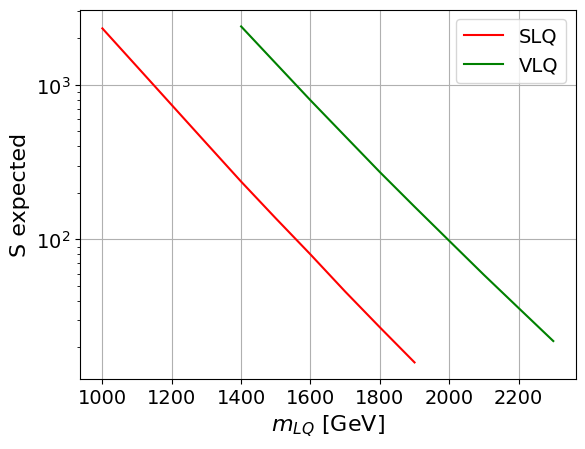

In [ ]:
plt.plot(masses_SLQ, S_expected_SLQ, color='red', label='SLQ')
plt.plot(masses_VLQ, S_expected_VLQ, color='green', label='VLQ')
plt.yscale('log')
plt.xlabel("$m_{LQ}$ [GeV]", fontsize=16)
plt.ylabel("S expected", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize=14)
plt.show()

In [ ]:
matched_VLQ_masses = []

for s_ev in S_expected_SLQ:
    # buscamos la VLQ que tenga la menor diferencia de eventos
    idx_match = np.argmin([abs(vlq_ev - s_ev) for vlq_ev in S_expected_VLQ])
    matched_mass = masses_VLQ[idx_match]
    matched_VLQ_masses.append(matched_mass)

# Mostrar resultados
for slq, s_ev, vlq, v_ev in zip(masses_SLQ, S_expected_SLQ, matched_VLQ_masses,
                                 [S_expected_VLQ[masses_VLQ.index(m)] for m in matched_VLQ_masses]):
    print(f"SLQ {slq} GeV ({s_ev} ev)  -> VLQ {vlq} GeV ({v_ev} ev)")

SLQ 1000 GeV (2325 ev)  -> VLQ 1400 GeV (2394 ev)
SLQ 1100 GeV (1314 ev)  -> VLQ 1500 GeV (1380 ev)
SLQ 1200 GeV (742 ev)  -> VLQ 1600 GeV (796 ev)
SLQ 1300 GeV (419 ev)  -> VLQ 1700 GeV (466 ev)
SLQ 1400 GeV (237 ev)  -> VLQ 1800 GeV (273 ev)
SLQ 1500 GeV (137 ev)  -> VLQ 1900 GeV (163 ev)
SLQ 1600 GeV (80 ev)  -> VLQ 2000 GeV (98 ev)
SLQ 1700 GeV (46 ev)  -> VLQ 2200 GeV (36 ev)
SLQ 1800 GeV (27 ev)  -> VLQ 2300 GeV (22 ev)
SLQ 1900 GeV (16 ev)  -> VLQ 2300 GeV (22 ev)


### Plot

In [ ]:
def plot_variable(var_name_aux, SLQ_data, VLQ_data, SM_data,
                  masses_SLQ, masses_VLQ,
                  bins=25, range=[20,2500], logy=True):

    var_name = feats_label.index(var_name_aux)

    plt.figure(figsize=(6,5))

    # --- Señal SLQ ---
    colors_SLQ = ['red', 'darkorange', 'orange', 'purple']  # ajustar según # de masas
    for i, m in enumerate(masses_SLQ):
        data = SLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_SLQ[i], histtype='step', label=f'm($LQ_3^S$)={m} GeV')

    # --- Señal VLQ ---
    colors_VLQ = ['lime', 'dodgerblue', 'cyan', 'magenta']  # ajustar según # de masas
    for i, m in enumerate(masses_VLQ):
        data = VLQ_data[m][:,var_name]
        plt.hist(data[:], bins=bins, lw=3, range=range, density=True,
                 edgecolor=colors_VLQ[i], histtype='step', label=f'm($LQ_3^V$)={m} GeV')

    # --- Background stacked ---
    # se combinan todos los backgrounds en un solo histograma apilado
    bg_data_list = [
        SM_data['tt'][:int(len(SM_data['tt'])*fidxsec_SM['tt']/totalcrossSM),var_name],
        np.concatenate([SM_data['singletP1'][:int(len(SM_data['singletP1'])*fidxsec_SM['singletP1']/totalcrossSM),var_name], SM_data['singletP2'][:int(len(SM_data['singletP2'])*fidxsec_SM['singletP2']/totalcrossSM),var_name]]),
        SM_data['Wbbjets'][:int(len(SM_data['Wbbjets'])*fidxsec_SM['Wbbjets']/totalcrossSM),var_name],
        np.concatenate([SM_data['ttW'][:int(len(SM_data['ttW'])*fidxsec_SM['ttW']/totalcrossSM),var_name], SM_data['ttZ'][:int(len(SM_data['ttZ'])*fidxsec_SM['ttZ']/totalcrossSM),var_name], SM_data['ttH'][:int(len(SM_data['ttH'])*fidxsec_SM['ttH']/totalcrossSM),var_name]])
    ]

    bg_colors = ['blue','green','magenta','black']
    plt.hist([d[:] for d in bg_data_list], bins=bins, lw=2, range=range, density=True,
             stacked=True, color=bg_colors, label=[r'$t\bar{t}$',r'single $t$',r'W+j',r'fake $t\bar{t}$, $t\bar{t}V$, $t\bar{t}H$'])

    # --- Configuración del plot ---
    plt.grid()
    plt.xlabel(f"{feats_label[var_name]} [GeV]", fontsize=14)
    # plt.xlabel(r"$E_T^{miss}$ [GeV]", fontsize=14)
    # plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$H_T$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m_T(E_T^{miss},\tau)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$m(\tau_h, b_1)$ [GeV]", fontsize=14)
    # plt.xlabel(r"$\Delta R(b_1, b_2)$", fontsize=14)
    plt.xlabel(r"$N_{b\mathrm{-jets}}$", fontsize=14)

    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(range)

    if logy:
        plt.yscale('log')
        plt.ylim(1e-7,1e-2)
        plt.ylim(1e-2,1e-0)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=10, loc='upper right')
    # plt.savefig(mainfolder + "saved-results/MET.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/sT.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/HT.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/mT-METtau.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/m-taub1.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/dR-b1b2.pdf", bbox_inches='tight')
    # plt.savefig(mainfolder + "saved-results/num-bjets.pdf", bbox_inches='tight')
    plt.show()

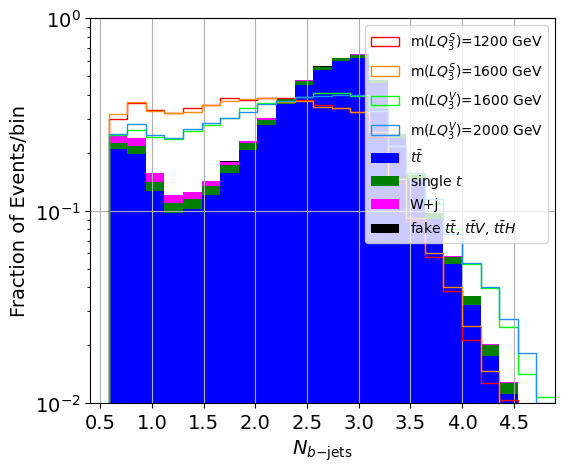

In [ ]:
# Ejemplo: plot pT del tau
plot_variable('dR-b1b2', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=25,
            #   range=[20,2500] # MET
            #   range=[0,5000] # sT and HT and mT-METtau and m-b1b2
              range=[0.4,4.9] # dR-b1b2
              )

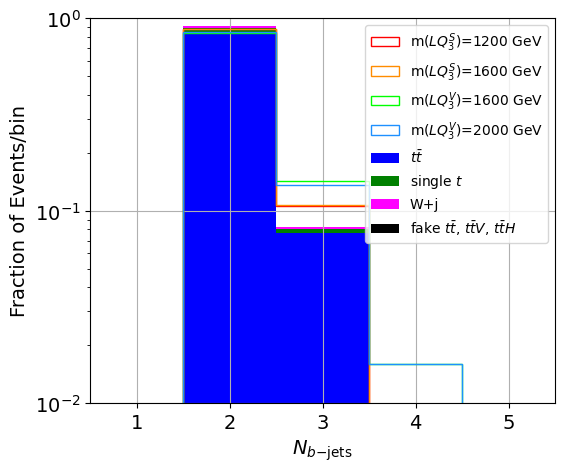

In [ ]:
# Ejemplo: plot pT del tau
plot_variable('num-bjets', X_SLQ_all, X_VLQ_all, X_B_all,
              masses_SLQ=[1200,1600],
              masses_VLQ=[1600,2000],
              bins=5,
            #   range=[20,2500] # MET
            #   range=[0,5000] # sT and HT and mT-METtau and m-b1b2
            #   range=[0.4,4.9] # dR-b1b2
              range=[0.5,5.5]
              )

In [ ]:
df_SLQ_all[1200].keys()

Index(['b1-pt', 'b1-eta', 'b1-phi', 'b2-pt', 'b2-eta', 'b2-phi', 'tau-pt',
       'tau-eta', 'tau-phi', 'jet1-pt', 'jet1-eta', 'jet1-phi', 'jet2-pt',
       'jet2-eta', 'jet2-phi', 'MET-pt', 'MET-phi', 'HT-pt', 'num-jets',
       'num-bjets', 'dR-taub1', 'dR-taub2', 'dR-b1b2', 'dR-j1b1', 'dR-j1b2',
       'dR-j1tau', 'dR-j2b1', 'dR-j2b2', 'dR-j2tau', 'dR-j1j2', 'dphi-METb1',
       'dphi-METb2', 'dphi-METtau', 'dphi-METj1', 'dphi-METj2', 'm-taub1',
       'm-taub2', 'm-b1b2', 'm-j1b1', 'm-j1b2', 'm-j1tau', 'm-j2b1', 'm-j2b2',
       'm-j2tau', 'm-j1j2', 'mT-METb1', 'mT-METb2', 'mT-METtau', 'mT-METj1',
       'mT-METj2', 'mTb1b2', 'mTj1j2', 'sT'],
      dtype='object')

# 1. DATA FORMAT for CLASSIFIERS

In [ ]:
# to save memory
del X_SLQ_all
del X_VLQ_all
del X_B_all

In [ ]:
# DATA WITH UNCERTAINTIES

factor_down = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_down = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_down.columns:
    df_B_all_down["sT"] = df_B_all_down["sT"] * (1 - factor_down)



df_SLQ_all_down = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_SLQ_all_down[key] = df_sample



df_VLQ_all_down = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 - factor_down)

    df_VLQ_all_down[key] = df_sample

In [ ]:
# DATA WITH UNCERTAINTIES

factor_up = 0.1


df_B_aux = pd.concat(df_B_all.values(), ignore_index=True)

df_B_all_up = df_B_aux.sample(n=400000, random_state=42).reset_index(drop=True)

if "sT" in df_B_all_up.columns:
    df_B_all_up["sT"] = df_B_all_up["sT"] * (1 + factor_up)



df_SLQ_all_up = {}
for key, df in df_SLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_SLQ_all_up[key] = df_sample



df_VLQ_all_up = {}
for key, df in df_VLQ_all.items():
    df_sample = df.sample(n=min(20000, len(df)), random_state=42).reset_index(drop=True)

    if "sT" in df_sample.columns:
        df_sample["sT"] = df_sample["sT"] * (1 + factor_up)

    df_VLQ_all_up[key] = df_sample

In [ ]:
# ---------------------------
# Concatenate all for normalization
# ---------------------------
df_SM = pd.concat(df_B_all.values(), ignore_index=True)
del df_B_all

df_all = pd.concat([df_SM] + list(df_SLQ_all.values()) + list(df_VLQ_all.values()), ignore_index=True)

# ---------------------------
# Normalization
# ---------------------------
scaler = MinMaxScaler()
scaler.fit(df_all)

# Save the scaler
joblib.dump(scaler, mainfolder + 'saved-models/scaler_features.pkl')

# Apply normalization
df_SM_norm = pd.DataFrame(scaler.transform(df_SM), columns=df_SM.columns)
df_SLQ_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all[mass]), columns=df_SLQ_all[mass].columns) for mass in df_SLQ_all}
df_VLQ_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all[mass]), columns=df_VLQ_all[mass].columns) for mass in df_VLQ_all}






# ---------------------------
# Divide datasets into train/val/test/pseudo
# ---------------------------
def split_class(df, test_ratio=0.25, val_ratio=0.10, pseudo_ratio=0.25):
    X = df.values
    aux_val_ratio = val_ratio / (1 - test_ratio)
    aux_pseudo_ratio = pseudo_ratio / (1 - test_ratio - val_ratio)

    X_aux, X_test = train_test_split(X, test_size=test_ratio, random_state=42, shuffle=True)
    X_aux2, X_val = train_test_split(X_aux, test_size=aux_val_ratio, random_state=42, shuffle=True)
    X_train, X_pseudo = train_test_split(X_aux2, test_size=aux_pseudo_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, X_pseudo



# ---------------------------
# Divide the datasets
# ---------------------------
split_SM = split_class(df_SM_norm)
split_SLQ = {mass: split_class(df_SLQ_norm[mass]) for mass in df_SLQ_norm}
split_VLQ = {mass: split_class(df_VLQ_norm[mass]) for mass in df_VLQ_norm}



# Example of how to use them
X_train_SM, X_val_SM, X_test_SM, X_pseudo_SM = split_SM
X_train_SLQ1200, X_val_SLQ1200, X_test_SLQ1200, X_pseudo_SLQ1200 = split_SLQ[1200]
X_train_VLQ1600, X_val_VLQ1600, X_test_VLQ1600, X_pseudo_VLQ1600 = split_VLQ[1600]

print('')
print('X_train_SM : ', X_train_SM.shape)
print('X_val_SM : ', X_val_SM.shape)
print('X_test_SM : ', X_test_SM.shape)
print('X_pseudo_SM : ', X_pseudo_SM.shape)

print('')
print('X_train_SLQ1200 : ', X_train_SLQ1200.shape)
print('X_val_SLQ1200 : ', X_val_SLQ1200.shape)
print('X_test_SLQ1200 : ', X_test_SLQ1200.shape)
print('X_pseudo_SLQ1200 : ', X_pseudo_SLQ1200.shape)

print('')
print('X_train_VLQ1600 : ', X_train_VLQ1600.shape)
print('X_val_VLQ1600 : ', X_val_VLQ1600.shape)
print('X_test_VLQ1600 : ', X_test_VLQ1600.shape)
print('X_pseudo_VLQ1600 : ', X_pseudo_VLQ1600.shape)


X_train_SM :  (400000, 53)
X_val_SM :  (100000, 53)
X_test_SM :  (250000, 53)
X_pseudo_SM :  (250000, 53)

X_train_SLQ1200 :  (20000, 53)
X_val_SLQ1200 :  (5000, 53)
X_test_SLQ1200 :  (12500, 53)
X_pseudo_SLQ1200 :  (12500, 53)

X_train_VLQ1600 :  (20000, 53)
X_val_VLQ1600 :  (5000, 53)
X_test_VLQ1600 :  (12500, 53)
X_pseudo_VLQ1600 :  (12500, 53)


In [ ]:
# to save memory
del df_SM
del df_SLQ_all
del df_VLQ_all

In [ ]:

# Apply normalization
df_SM_down_norm = pd.DataFrame(scaler.transform(df_B_all_down), columns=df_B_all_down.columns)
df_SLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_down[mass]), columns=df_SLQ_all_down[mass].columns) for mass in df_SLQ_all_down}
df_VLQ_down_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_down[mass]), columns=df_VLQ_all_down[mass].columns) for mass in df_VLQ_all_down}

# to save memory
del df_B_all_down
del df_SLQ_all_down
del df_VLQ_all_down

In [ ]:

# Apply normalization
df_SM_up_norm = pd.DataFrame(scaler.transform(df_B_all_up), columns=df_B_all_up.columns)
df_SLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_SLQ_all_up[mass]), columns=df_SLQ_all_up[mass].columns) for mass in df_SLQ_all_up}
df_VLQ_up_norm = {mass: pd.DataFrame(scaler.transform(df_VLQ_all_up[mass]), columns=df_VLQ_all_up[mass].columns) for mass in df_VLQ_all_up}

# to save memory
del df_B_all_up
del df_SLQ_all_up
del df_VLQ_all_up

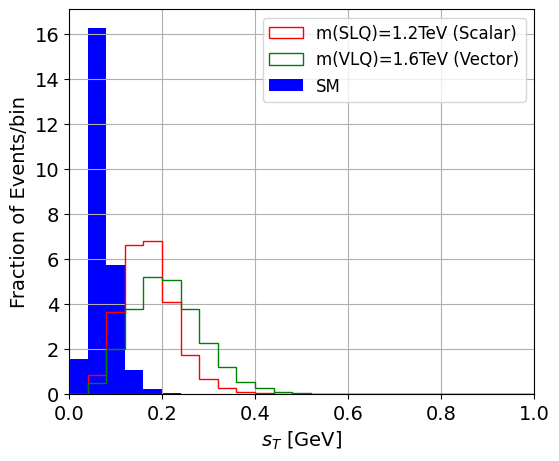

In [ ]:
def plot_feat(slq_mass, vlq_mass, feat_SLQ, feat_VLQ, feat_SM, slq_label=None, vlq_label=None):
    plt.figure(figsize=(6,5))

    plt.hist(feat_SLQ, bins=25, lw=2, range=[0,1], density=True,
             edgecolor='red', histtype='step', label=slq_label)

    plt.hist(feat_VLQ, bins=25, lw=2, range=[0,1], density=True,
             edgecolor='green', histtype='step', label=vlq_label)

    plt.hist(feat_SM, bins=25, lw=2, range=[0,1], density=True, stacked=True, color=["blue"], label='SM')

    plt.grid()
#     plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
    plt.ylabel("Fraction of Events/bin", fontsize=14)
    plt.xlim(0,1)
#     plt.ylim(1e-5,5e-3)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
#     plt.yscale('log')
    plt.legend(fontsize=12)
#     plt.show()


feat = 'sT'

plot_feat(
    1200, 1600,
    df_SLQ_norm[1200][feat],
    df_VLQ_norm[1600][feat],
    df_SM_norm[feat],
    slq_label=r'm(SLQ)=1.2TeV (Scalar)',
    vlq_label=r'm(VLQ)=1.6TeV (Vector)'
)
plt.xlabel(r"$s_T$ [GeV]", fontsize=14)
plt.show()

# SM vs LQ

In [ ]:
# Combine all LQ in a single DataFrame
df_LQ_list = list(df_SLQ_norm.values()) + list(df_VLQ_norm.values())
df_LQ_norm = pd.concat(df_LQ_list, ignore_index=True)


# Check, same number of events
n_SM = len(df_SM_norm)
n_LQ = len(df_LQ_norm)
n_events = min(n_SM, n_LQ)

print(n_SM, n_LQ, n_events)

df_SM_sample = df_SM_norm.sample(n=n_events, random_state=42)
df_LQ_sample = df_LQ_norm.sample(n=n_events, random_state=42)


# Create X, y
X = pd.concat([df_SM_sample, df_LQ_sample], ignore_index=True)
y = np.hstack([np.zeros(n_events), np.ones(n_events)])  # 0=SM, 1=LQ


def split_class(X, Y, test_ratio=0.25, val_ratio=0.25):

    aux_val_ratio = val_ratio / (1 - test_ratio)

    X_aux, X_test, Y_aux, Y_test = train_test_split(X, Y, test_size=test_ratio, random_state=42, shuffle=True)
    X_train, X_val, Y_train, Y_val = train_test_split(X_aux, Y_aux, test_size=val_ratio, random_state=42, shuffle=True)

    return X_train, X_val, X_test, Y_train, Y_val, Y_test


# Divide into train, validation and test
X_train, X_val, X_test, y_train, y_val, y_test = split_class(X, y)


print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

1000000 1000000 1000000
(1125000, 53)
(375000, 53)
(500000, 53)


In [ ]:
# Combine all LQ in a single DataFrame
df_LQ_down_list = list(df_SLQ_down_norm.values()) + list(df_VLQ_down_norm.values())
df_LQ_down_norm = pd.concat(df_LQ_down_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_down_norm), len(df_LQ_down_norm))


# Create X, y
X_test_down = pd.concat([df_SM_down_norm, df_LQ_down_norm], ignore_index=True)
y_test_down = np.hstack([np.zeros(len(df_SM_down_norm)), np.ones(len(df_LQ_down_norm))])  # 0=SM, 1=LQ


print(X_test_down.shape)
print(y_test_down.shape)

400000 400000
(800000, 53)
(800000,)


In [ ]:
# Combine all LQ in a single DataFrame
df_LQ_up_list = list(df_SLQ_up_norm.values()) + list(df_VLQ_up_norm.values())
df_LQ_up_norm = pd.concat(df_LQ_up_list, ignore_index=True)

# Check, same number of events
print(len(df_SM_up_norm), len(df_LQ_up_norm))


# Create X, y
X_test_up = pd.concat([df_SM_up_norm, df_LQ_up_norm], ignore_index=True)
y_test_up = np.hstack([np.zeros(len(df_SM_up_norm)), np.ones(len(df_LQ_up_norm))])  # 0=SM, 1=LQ


print(X_test_up.shape)
print(y_test_up.shape)

400000 400000
(800000, 53)
(800000,)


In [ ]:
# # Train
# xgb_clf = XGBClassifier(
#     n_estimators=1500,
#     max_depth=5,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     use_label_encoder=False,
#     eval_metric='logloss',
#     early_stopping_rounds=50,
#     tree_method='hist'
# )

# xgb_clf.fit(X_train, y_train,
#             eval_set=[(X_train, y_train),
#                       (X_val, y_val)],
#             verbose=True)


# # SAVE
# xgb_clf.save_model(mainfolder + "saved-models/modelA_SMLQ_14TeV_full.json")

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [20:09:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[0]	validation_0-logloss:0.65170	validation_1-logloss:0.65169
[1]	validation_0-logloss:0.61263	validation_1-logloss:0.61260
[2]	validation_0-logloss:0.57832	validation_1-logloss:0.57828
[3]	validation_0-logloss:0.54727	validation_1-logloss:0.54721
[4]	validation_0-logloss:0.51723	validation_1-logloss:0.51716
[5]	validation_0-logloss:0.48952	validation_1-logloss:0.48945
[6]	validation_0-logloss:0.46410	validation_1-logloss:0.46402
[7]	validation_0-logloss:0.44051	validation_1-logloss:0.44042
[8]	validation_0-logloss:0.41974	validation_1-logloss:0.41966
[9]	validation_0-logloss:0.39958	validation_1-logloss:0.39950
[10]	validation_0-logloss:0.38068	validation_1-logloss:0.38060
[11]	validation_0-logloss:0.36327	validation_1-logloss:0.36319
[12]	validation_0-logloss:0.34697	validation_1-logloss:0.34690
[13]	validation_0-logloss:0.33258	validation_1-logloss:0.33251
[14]	validation_0-logloss:0.31832	validation_1-logloss:0.31826
[15]	validation_0-logloss:0.30492	validation_1-logloss:0.30487
[1

Accuracy: 0.973, ROC-AUC: 0.99660


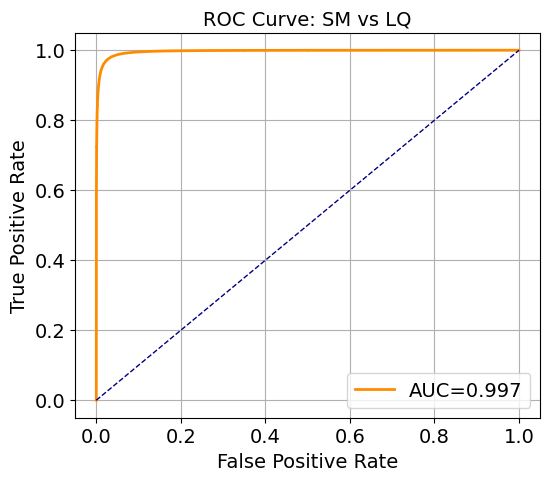

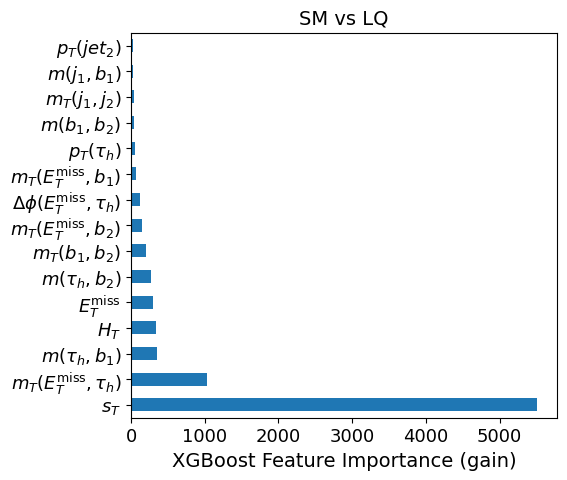

[52, 47, 35, 17, 15, 36, 50, 46, 32, 45, 6, 37, 51, 38, 12]


In [ ]:
# LOAD
xgb_clf = XGBClassifier()
xgb_clf.load_model(mainfolder + "saved-models/modelA_SMLQ_14TeV_full.json")


# Evaluate
y_pred = xgb_clf.predict(X_test)
y_pred_proba = xgb_clf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {acc:.3f}, ROC-AUC: {auc:.5f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


# Feature importance
keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$'])

feature_important = xgb_clf.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=14).remove()
plt.title(r'SM vs LQ', fontsize=14)
plt.savefig(mainfolder + "saved-results/XG_feature_importance_classA.pdf", bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

Accuracy: 0.976, ROC-AUC: 0.99730
Accuracy: 0.976, ROC-AUC: 0.99728


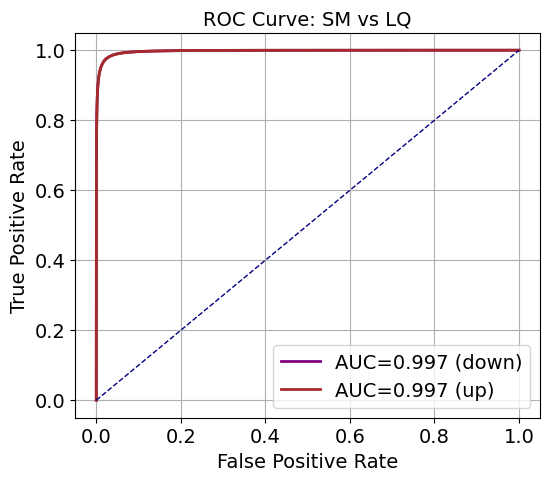

In [ ]:

# Evaluate
y_pred_down = xgb_clf.predict(X_test_down)
y_pred_proba_down = xgb_clf.predict_proba(X_test_down)[:,1]

acc_down = accuracy_score(y_test_down, y_pred_down)
auc_down = roc_auc_score(y_test_down, y_pred_proba_down)
print(f"Accuracy: {acc_down:.3f}, ROC-AUC: {auc_down:.5f}")


# Evaluate
y_pred_up = xgb_clf.predict(X_test_up)
y_pred_proba_up = xgb_clf.predict_proba(X_test_up)[:,1]

acc_up = accuracy_score(y_test_up, y_pred_up)
auc_up = roc_auc_score(y_test_up, y_pred_proba_up)
print(f"Accuracy: {acc_up:.3f}, ROC-AUC: {auc_up:.5f}")

# ROC curve
fpr_down, tpr_down, _ = roc_curve(y_test_down, y_pred_proba_down)
fpr_up, tpr_up, _ = roc_curve(y_test_up, y_pred_proba_up)

plt.figure(figsize=(6,5))
plt.plot(fpr_down, tpr_down, color='purple', lw=2, label=f'AUC={auc_down:.3f} (down)')
plt.plot(fpr_up, tpr_up, color='brown', lw=2, label=f'AUC={auc_up:.3f} (up)')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SM vs LQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + "saved-results/ROC_classA.pdf", bbox_inches='tight')
plt.show()


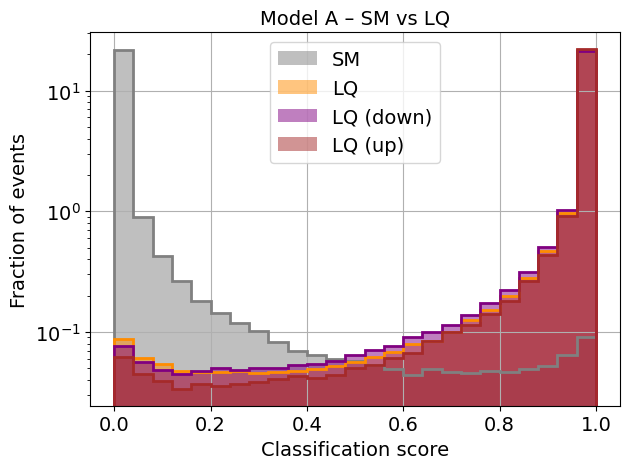

In [ ]:

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='darkorange', linewidth=2)

plt.hist(y_pred_proba[y_test < 0.5], bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
plt.hist(y_pred_proba[y_test > 0.5], bins=25, range=(0,1), density=True, color='darkorange', alpha=0.5, label=f'LQ')#\nmean: {np.mean(pred_s):.2f}')

plt.hist(y_pred_proba_down[y_test_down > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='purple', linewidth=2)
plt.hist(y_pred_proba_down[y_test_down > 0.5], bins=25, range=(0,1), density=True, color='purple', alpha=0.5, label=f'LQ (down)')#\nmean: {np.mean(pred_s):.2f}')

plt.hist(y_pred_proba_up[y_test_up > 0.5], bins=25, range=(0,1), density=True, histtype='step', color='brown', linewidth=2)
plt.hist(y_pred_proba_up[y_test_up > 0.5], bins=25, range=(0,1), density=True, color='brown', alpha=0.5, label=f'LQ (up)')#\nmean: {np.mean(pred_s):.2f}')

plt.yscale('log')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model A – SM vs LQ', fontsize=14)
plt.xlabel("Classification score", fontsize=14)
plt.ylabel("Fraction of events", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)

plt.tight_layout()
# plt.savefig(mainfolder + 'saved-results/output_classA_multi.pdf', bbox_inches='tight')
plt.show()

## Compute S_pred for pseudo-experiments

In [ ]:
# output of all the background events
scores_B = xgb_clf.predict_proba( df_SM_norm )[:, 1]

# output of all the signal events (for the pdf of the general LQ case)
scores_S = xgb_clf.predict_proba( df_LQ_norm )[:, 1]

In [ ]:
# output of all the signal events per class (to build the pseudo-experiments)
scores_S_SLQ = {mass: xgb_clf.predict_proba(df_SLQ_norm[mass])[:, 1] for mass in df_SLQ_norm}
scores_S_VLQ = {mass: xgb_clf.predict_proba(df_VLQ_norm[mass])[:, 1] for mass in df_VLQ_norm}

In [ ]:
def Z_asimov(S, B):
    if S <= 0 or B <= 0:
        return 0
    return np.sqrt(2 * ((S+B) * np.log(1 + S/B) - S))

In [ ]:
bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scores_B, bins=bins, density=True)
hist_S, _ = np.histogram(scores_S, bins=bins, density=True) # the signal pdf is a generic (mixture of all) to be general


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

In [ ]:
# FOR SLQ #

S_expected = S_expected_SLQ


n_pseudo = 1000


# to save
S_mean_fit_N = {}
S_std_fit_N  = {}
Z_fit_N = {}



for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit_N[S_it] = []
    S_std_fit_N[S_it]  = []
    Z_fit_N[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S_SLQ[masses_SLQ[ii_S]], N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit_N[S_it].append(mean_muS)
    S_std_fit_N[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit_N[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  2325
S = 1859.1409055064871 +- 48.35175682387624
Z = 79.98744308975039


----------------
S_expected =  1314
S = 1144.717914854991 +- 39.64026584814028
Z = 55.76149909221306


----------------
S_expected =  742
S = 689.8571094607873 +- 34.182503731995524
Z = 36.56323482327153


----------------
S_expected =  419
S = 407.9962092679542 +- 23.909751433133273
Z = 25.782031315775615


----------------
S_expected =  237
S = 237.9883643216142 +- 19.716771502798693
Z = 15.678436613753284


----------------
S_expected =  137
S = 141.2754009517994 +- 17.16874968855835
Z = 10.137918514342621


----------------
S_expected =  80
S = 84.8884030032192 +- 15.152633216908308
Z = 6.18835477633334


----------------
S_expected =  46
S = 49.91367080534511 +- 13.434307756690082
Z = 3.2268795388120624


----------------
S_expected =  27
S = 29.942010616793045 +- 12.827450755037017
Z = 2.726495679108104


----------------
S_expected =  16
S = 17.982601522763304 +- 11.521823910

/tmp/ipykernel_15493/1030940870.py:78: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


In [ ]:
# FOR VLQ #

S_expected = S_expected_SLQ # same number of events


n_pseudo = 1000


# to save
S_mean_fit_V = {}
S_std_fit_V  = {}
Z_fit_V = {}



for ii_S, S_it in enumerate(S_expected):
    print('\n----------------')
    print('S_expected = ', S_it)

    S_mean_fit_V[S_it] = []
    S_std_fit_V[S_it]  = []
    Z_fit_V[S_it] = []


    muS_fits = []
    muB_fits = []

    for n_it in range(n_pseudo):

        # 1) pseudo experiment
        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_it)

        sample_B = np.random.choice(scores_B, N_B, replace=True)
        sample_S = np.random.choice(scores_S_VLQ[masses_VLQ[ii_S]], N_S, replace=True)

        data_scores = np.concatenate([sample_B, sample_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_it, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits.append(muS_fit)
        muB_fits.append(muB_fit)


    mean_muB = np.mean(muB_fits)

    mean_muS = np.mean(muS_fits)
    std_muS  = np.std(muS_fits)

    S_mean_fit_V[S_it].append(mean_muS)
    S_std_fit_V[S_it].append(std_muS)


    # significance
    logL_hat = -neg_logL([mean_muS, mean_muB])
    logL_null = -neg_logL([0, mean_muB])

    q0 = -2 * (logL_null - logL_hat)

    Z = np.sqrt(q0)

    Z_fit_V[S_it].append(Z)

    print("S =", mean_muS, "+-", std_muS)
    print("Z =", Z)
    print('')



----------------
S_expected =  2325
S = 2263.6467329291963 +- 66.93539309308471
Z = 93.29563644697274


----------------
S_expected =  1314
S = 1295.9267220527938 +- 36.17943784845613
Z = 63.13184123351911


----------------
S_expected =  742
S = 741.5595220982106 +- 28.947696622048184
Z = 42.17490281774471


----------------
S_expected =  419
S = 422.9327267510059 +- 23.06221107507441
Z = 25.07737833086711


----------------
S_expected =  237
S = 242.46173027139133 +- 20.156663676766644
Z = 15.697317348497265


----------------
S_expected =  137
S = 142.19188437101263 +- 17.76010465621391
Z = 10.714616159730571


----------------
S_expected =  80
S = 83.48768089083784 +- 14.631315338862137
Z = 5.612562727478481


----------------
S_expected =  46
S = 47.758233190182175 +- 13.47730568420232
Z = 3.889273766311812


----------------
S_expected =  27


/tmp/ipykernel_15493/2772170123.py:78: RuntimeWarning: invalid value encountered in sqrt
  Z = np.sqrt(q0)


S = 28.930040869028467 +- 12.712089898700354
Z = nan


----------------
S_expected =  16
S = 17.118662176263793 +- 11.71965997848284
Z = 1.4459736940294297



In [ ]:
# mean between scalar and vector
S_mean_fit_both = []
S_std_fit_both = []

for i in S_mean_fit_N:

    S_mean_fit_both.append( np.mean([S_mean_fit_N[i][0], S_mean_fit_V[i][0]]) )
    S_std_fit_both.append( np.mean([S_std_fit_N[i][0], S_std_fit_V[i][0]]) )


# SLQ vs VLQ (include Poisson S_expected)

In [ ]:
X_train_list, y_train_list, S_poiss_train_list = [], [], []
X_val_list,   y_val_list,   S_poiss_val_list   = [], [], []
X_test_list,  y_test_list,  S_poiss_test_list  = [], [], []

for iit, m_s in enumerate(masses_SLQ):

        # -------- SLQ --------
        X_train_s, X_val_s, X_test_s, _ = split_SLQ[masses_SLQ[iit]]

        X_train_list.append(X_train_s)
        y_train_list.append(np.zeros(len(X_train_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_train_s))
        S_poiss_train_list.append(poisson_samples)

        X_val_list.append(X_val_s)
        y_val_list.append(np.zeros(len(X_val_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_val_s))
        S_poiss_val_list.append(poisson_samples)

        X_test_list.append(X_test_s)
        y_test_list.append(np.zeros(len(X_test_s)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_test_s))
        S_poiss_test_list.append(poisson_samples)


# for iit, m_v in enumerate(masses_VLQ):

        # -------- VLQ --------
        X_train_v, X_val_v, X_test_v, _ = split_VLQ[masses_VLQ[iit]]

        X_train_list.append(X_train_v)
        y_train_list.append(np.ones(len(X_train_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_train_v))
        S_poiss_train_list.append(poisson_samples)

        X_val_list.append(X_val_v)
        y_val_list.append(np.ones(len(X_val_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_val_v))
        S_poiss_val_list.append(poisson_samples)

        X_test_list.append(X_test_v)
        y_test_list.append(np.ones(len(X_test_v)))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(X_test_v))
        S_poiss_test_list.append(poisson_samples)


# Concatenate
# TRAIN
X_train_spin = np.vstack(X_train_list)
y_train_spin = np.concatenate(y_train_list)
S_poiss_train = np.concatenate(S_poiss_train_list)

# add S_poiss as extra feature
X_train_spin = np.column_stack([X_train_spin, S_poiss_train])


# VAL
X_val_spin = np.vstack(X_val_list)
y_val_spin = np.concatenate(y_val_list)
S_poiss_val = np.concatenate(S_poiss_val_list)

X_val_spin = np.column_stack([X_val_spin, S_poiss_val])


# TEST
X_test_spin = np.vstack(X_test_list)
y_test_spin = np.concatenate(y_test_list)
S_poiss_test = np.concatenate(S_poiss_test_list)

X_test_spin = np.column_stack([X_test_spin, S_poiss_test])


print(X_train_spin.shape)
print(X_val_spin.shape)
print(X_test_spin.shape)

(400000, 54)
(100000, 54)
(250000, 54)


In [ ]:
np.array(df_SLQ_down_norm[1800]).shape

(20000, 53)

In [ ]:
X_test_down_list,  y_test_down_list,  S_poiss_test_down_list  = [], [], []

for iit, m_s in enumerate(masses_SLQ):

        # -------- SLQ --------
        X_test_down_list.append(df_SLQ_down_norm[masses_SLQ[iit]])
        y_test_down_list.append(np.zeros(len(df_SLQ_down_norm[masses_SLQ[iit]])))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(df_SLQ_down_norm[masses_SLQ[iit]]))
        S_poiss_test_down_list.append(poisson_samples)


        # -------- VLQ --------
        X_test_down_list.append(df_VLQ_down_norm[masses_VLQ[iit]])
        y_test_down_list.append(np.ones(len(df_VLQ_down_norm[masses_VLQ[iit]])))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(df_VLQ_down_norm[masses_VLQ[iit]]))
        S_poiss_test_down_list.append(poisson_samples)


# Concatenate
# TEST
X_test_down_spin = np.vstack(X_test_down_list)
y_test_down_spin = np.concatenate(y_test_down_list)
S_poiss_test_down = np.concatenate(S_poiss_test_down_list)

X_test_down_spin = np.column_stack([X_test_down_spin, S_poiss_test_down])


print(X_test_down_spin.shape)
print(y_test_down_spin.shape)

(400000, 54)
(400000,)


In [ ]:
X_test_up_list,  y_test_up_list,  S_poiss_test_up_list  = [], [], []

for iit, m_s in enumerate(masses_SLQ):

        # -------- SLQ --------
        X_test_up_list.append(df_SLQ_up_norm[masses_SLQ[iit]])
        y_test_up_list.append(np.zeros(len(df_SLQ_up_norm[masses_SLQ[iit]])))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(df_SLQ_up_norm[masses_SLQ[iit]]))
        S_poiss_test_up_list.append(poisson_samples)


        # -------- VLQ --------
        X_test_up_list.append(df_VLQ_up_norm[masses_VLQ[iit]])
        y_test_up_list.append(np.ones(len(df_VLQ_up_norm[masses_VLQ[iit]])))
        poisson_samples = np.random.poisson(lam=S_mean_fit_both[iit], size=len(df_VLQ_up_norm[masses_VLQ[iit]]))
        S_poiss_test_up_list.append(poisson_samples)


# Concatenate
# TEST
X_test_up_spin = np.vstack(X_test_up_list)
y_test_up_spin = np.concatenate(y_test_up_list)
S_poiss_test_up = np.concatenate(S_poiss_test_up_list)

X_test_up_spin = np.column_stack([X_test_up_spin, S_poiss_test_up])


print(X_test_up_spin.shape)
print(y_test_up_spin.shape)

(400000, 54)
(400000,)


In [ ]:
classifier_spin = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    gamma=0.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

classifier_spin.fit(
    X_train_spin, y_train_spin,
    eval_set=[(X_train_spin, y_train_spin),
              (X_val_spin, y_val_spin)],
    verbose=True
)

classifier_spin.save_model(mainfolder + "saved-models/modelB_spin_S_poiss.json")

[0]	validation_0-logloss:0.68605	validation_1-logloss:0.68613
[1]	validation_0-logloss:0.67993	validation_1-logloss:0.68013
[2]	validation_0-logloss:0.67454	validation_1-logloss:0.67477
[3]	validation_0-logloss:0.66996	validation_1-logloss:0.67028
[4]	validation_0-logloss:0.66584	validation_1-logloss:0.66620
[5]	validation_0-logloss:0.66239	validation_1-logloss:0.66278
[6]	validation_0-logloss:0.65902	validation_1-logloss:0.65947
[7]	validation_0-logloss:0.65620	validation_1-logloss:0.65677
[8]	validation_0-logloss:0.65349	validation_1-logloss:0.65408
[9]	validation_0-logloss:0.65106	validation_1-logloss:0.65176
[10]	validation_0-logloss:0.64898	validation_1-logloss:0.64970
[11]	validation_0-logloss:0.64681	validation_1-logloss:0.64760
[12]	validation_0-logloss:0.64504	validation_1-logloss:0.64590
[13]	validation_0-logloss:0.64330	validation_1-logloss:0.64423
[14]	validation_0-logloss:0.64122	validation_1-logloss:0.64220
[15]	validation_0-logloss:0.63984	validation_1-logloss:0.64086
[1

Global AUC = 0.744979256928


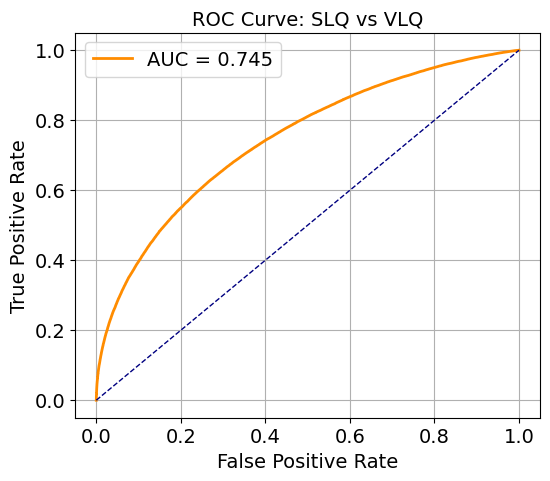

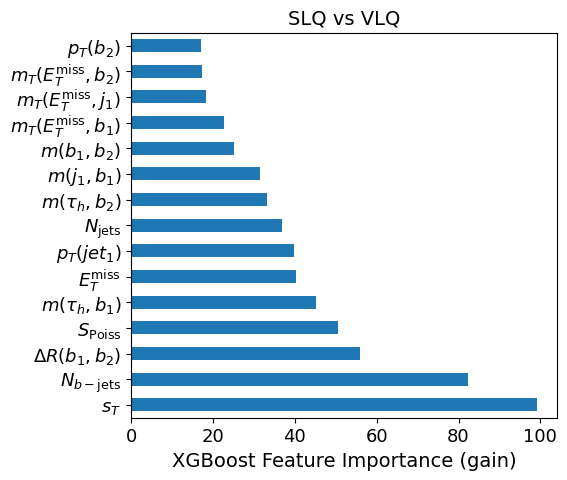

[52, 19, 22, 53, 35, 15, 9, 18, 36, 38, 37, 45, 48, 46, 3]


In [ ]:
# LOAD
classifier_spin = XGBClassifier()
classifier_spin.load_model(mainfolder + "saved-models/modelB_spin_S_poiss.json")


y_score = classifier_spin.predict_proba(X_test_spin)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_spin, y_score)
roc_auc = roc_auc_score(y_test_spin, y_score)

print("Global AUC =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SLQ vs VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
plt.savefig(mainfolder + 'saved-results/ROC_classB.pdf', bbox_inches='tight')
plt.show()




keys = np.array([r'$p_T(b_1)$',r'$\eta(b_1)$',r'$\phi(b_1)$',
                 r'$p_T(b_2)$',r'$\eta(b_2)$',r'$\phi(b_2)$',
                 r'$p_T(\tau_h)$',r'$\eta(\tau_h)$',r'$\phi(\tau_h)$',
                 r'$p_T(jet_1)$',r'$\eta(jet_1)$',r'$\phi(jet_1)$',
                 r'$p_T(jet_2)$',r'$\eta(jet_2)$',r'$\phi(jet_2)$',
                 r'$E_T^{\mathrm{miss}}$',r'$\phi(E_T^{\mathrm{miss}})$',
                 r'$H_T$',r'$N_{\mathrm{jets}}$',r'$N_{b-\mathrm{jets}}$',
                 r'$\Delta R(\tau_h, b_1)$',r'$\Delta R(\tau_h, b_2)$',r'$\Delta R(b_1, b_2)$',
                 r'$\Delta R(j_1, b_1)$',r'$\Delta R(j_1, b_2)$',r'$\Delta R(j_1, \tau_h)$',
                 r'$\Delta R(j_2, b_1)$',r'$\Delta R(j_2, b_2)$',r'$\Delta R(j_2, \tau_h)$',
                 r'$\Delta R(j_1, j_2)$',
#                  r'$\Delta \phi(\tau_h, b_1)$',r'$\Delta \phi(\tau_h, b_2)$',r'$\Delta \phi(b_1, b_2)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, b_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, b_2)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$\Delta \phi(E_T^{\mathrm{miss}}, j_1)$',r'$\Delta \phi(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m(\tau_h, b_1)$',r'$m(\tau_h, b_2)$',r'$m(b_1, b_2)$',
                 r'$m(j_1, b_1)$',r'$m(j_1, b_2)$',r'$m(j_1, \tau_h)$',
                 r'$m(j_2, b_1)$',r'$m(j_2, b_2)$',r'$m(j_2, \tau_h)$',
                 r'$m(j_1, j_2)$',
                 r'$m_T(E_T^{\mathrm{miss}}, b_1)$',r'$m_T(E_T^{\mathrm{miss}}, b_2)$',r'$m_T(E_T^{\mathrm{miss}}, \tau_h)$',
                 r'$m_T(E_T^{\mathrm{miss}}, j_1)$',r'$m_T(E_T^{\mathrm{miss}}, j_2)$',
                 r'$m_T(b_1, b_2)$',r'$m_T(j_1, j_2)$',r'$s_T$',
                #  r'$m_{\mathrm{LQ}}^{\mathrm{reg}}$',
                 r'$S_{\mathrm{Poiss}}$'])

feature_important = classifier_spin.get_booster().get_score(importance_type='gain')
values = list(feature_important.values())


data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(15, columns="score").plot(kind='barh',figsize=(5.5,5)) ## plot top 15 features
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel("XGBoost Feature Importance (gain)", fontsize=14)
plt.legend( fontsize=12).remove()
plt.title(r'SLQ vs VLQ', fontsize=14)
plt.savefig(mainfolder + 'saved-results/XG_feature_importance_classB.pdf', bbox_inches='tight')
plt.show()


# SELECT THE TOP INDICES
num_feats = 15

keys_list = list(keys)  # convert to list
top_names = data.nlargest(num_feats, columns="score").index.tolist()
feat_indices_LQSM = [keys_list.index(name) for name in top_names]

print(feat_indices_LQSM)

Global AUC (down) = 0.7567773069874999
Global AUC (up) = 0.744979256928


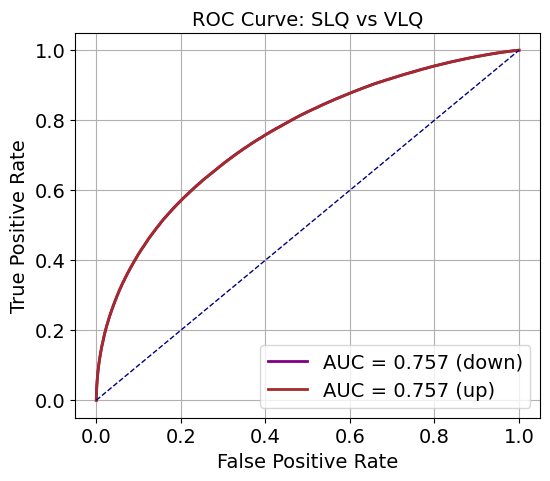

In [ ]:
y_score_down = classifier_spin.predict_proba(X_test_down_spin)[:, 1]


fpr_down, tpr_down, thresholds = roc_curve(y_test_down_spin, y_score_down)
roc_auc_down = roc_auc_score(y_test_down_spin, y_score_down)

print("Global AUC (down) =", roc_auc_down)


y_score_up = classifier_spin.predict_proba(X_test_up_spin)[:, 1]


fpr_up, tpr_up, thresholds = roc_curve(y_test_up_spin, y_score_up)
roc_auc_up = roc_auc_score(y_test_up_spin, y_score_up)

print("Global AUC (up) =", roc_auc)


plt.figure(figsize=(6,5))
plt.plot(fpr_down, tpr_down, color='purple', lw=2, label=f"AUC = {roc_auc_down:.3f} (down)")
plt.plot(fpr_up, tpr_up, color='brown', lw=2, label=f"AUC = {roc_auc_up:.3f} (up)")
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SLQ vs VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=14)
# plt.savefig(mainfolder + 'saved-results/ROC_classB.pdf', bbox_inches='tight')
plt.show()

$m_{LQ_3^S}=$1200 GeV,   AUC = 0.77454
$m_{LQ_3^S}=$1500 GeV,   AUC = 0.73320
$m_{LQ_3^S}=$1800 GeV,   AUC = 0.70283


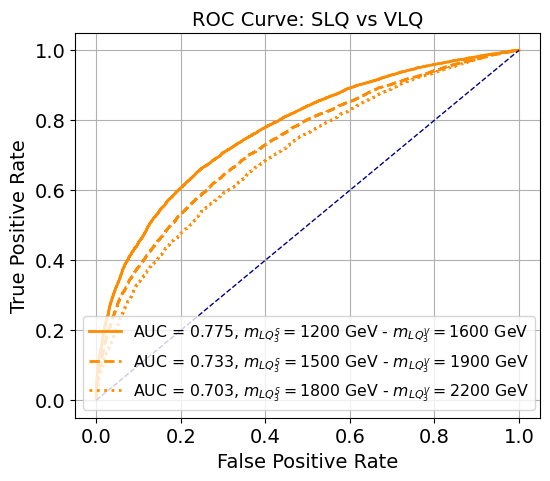

In [ ]:
S_column = X_test_spin[:, -1]

# mSLQ_plot = [1200, 1500, 1800]
# mVLQ_plot = [1600, 1900, 2200]

linestyles = ['-','-','-', '--','--','--', ':', ':', ':']
# colors_SLQ = ['lightcoral', 'red', 'firebrick']
# colors_VLQ = ['limegreen', 'green', 'darkgreen']

plt.figure(figsize=(6,5))

# evaluate per sector
for iit, S_id in enumerate(S_expected_SLQ):
    # if iit == 0 or iit == 1 or iit == 9:
    #     continue
    # else:
    if iit == 2 or iit == 5 or iit == 8:

        mask = (S_column < S_id * 1.1) & (0.9 * S_id < S_column)

        y_true_Spoiss = y_test_spin[mask]
        y_score_Spoiss = y_score[mask]

        fpr, tpr, _ = roc_curve(y_true_Spoiss, y_score_Spoiss)
        auc_sector = roc_auc_score(y_true_Spoiss, y_score_Spoiss)

        print(f"$m_{{LQ_3^S}}=${masses_SLQ[iit]} GeV,   AUC = {auc_sector:.5f}")


        plt.plot(fpr, tpr, color='darkorange', linestyle=linestyles[iit], lw=2, label=f"AUC = {auc_sector:.3f}, $m_{{LQ_3^S}}=${masses_SLQ[iit]} GeV - $m_{{LQ_3^V}}=${masses_VLQ[iit]} GeV")



plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve: SLQ vs VLQ", fontsize=14)
plt.grid(True)
plt.legend(fontsize=11.3)
# plt.savefig(mainfolder + 'saved-results/ROC_classB_multi.pdf', bbox_inches='tight')
plt.show()

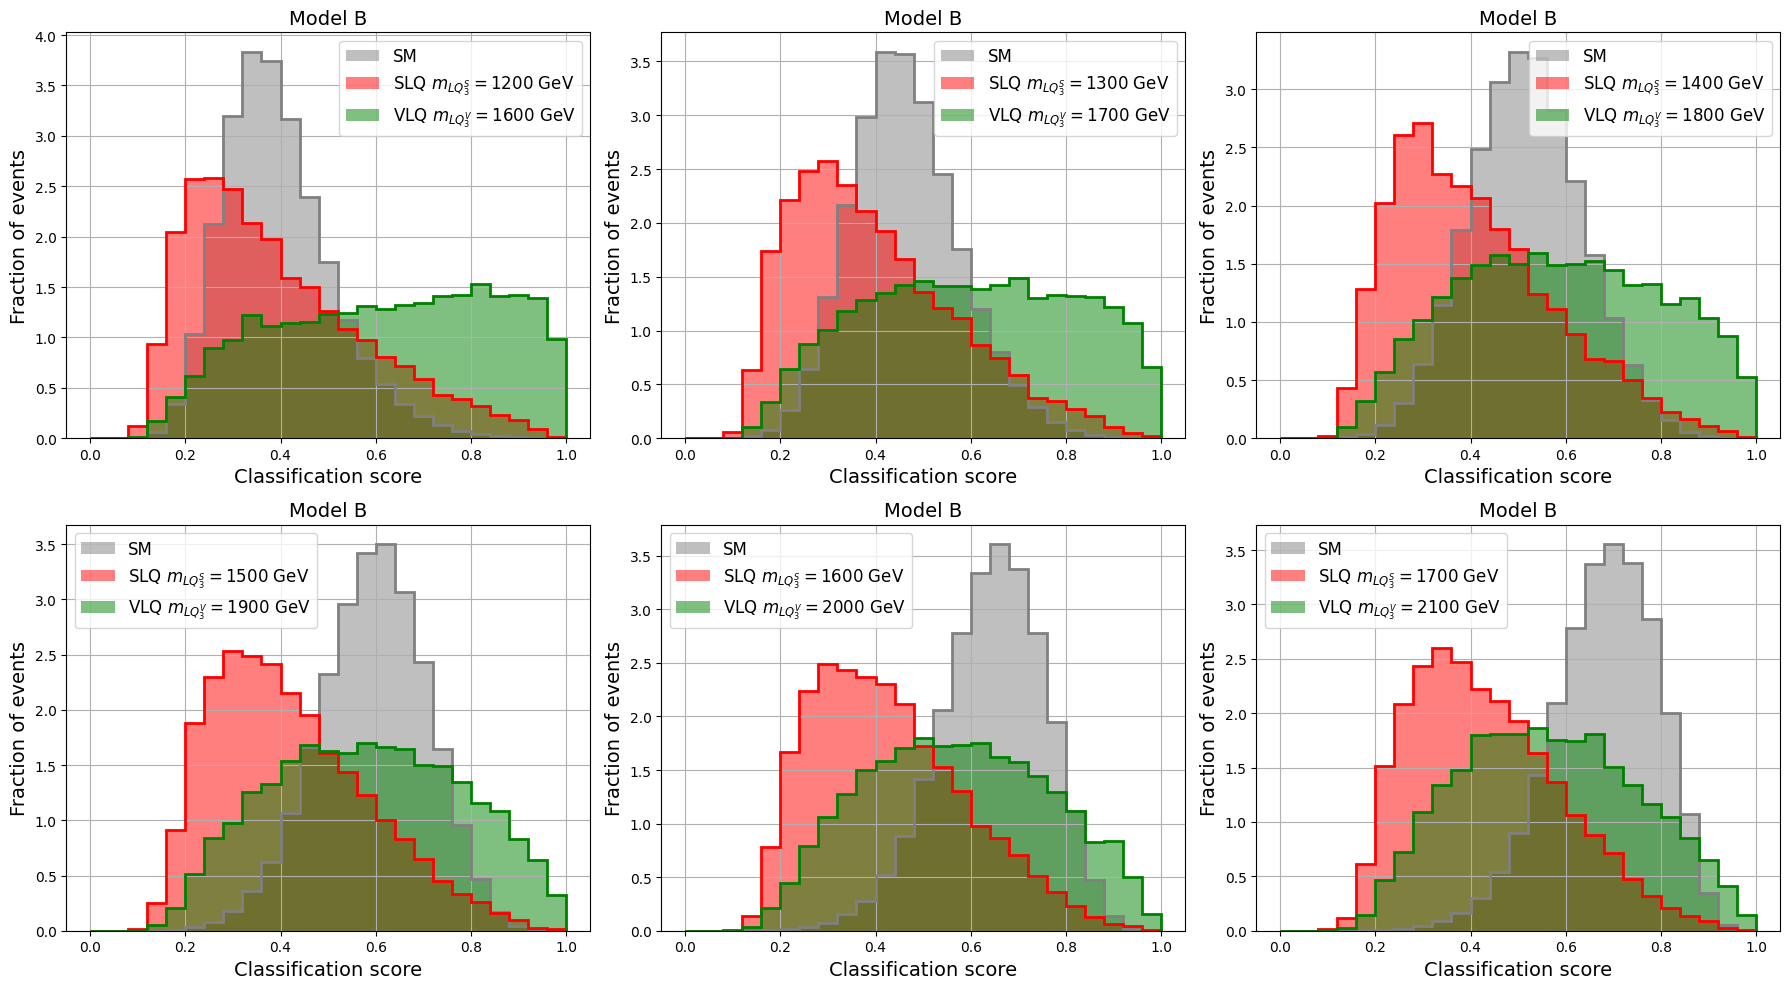

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

for iit, S_id in enumerate(S_expected_SLQ):
    if iit == 0 or iit == 1 or iit == 8 or iit == 9:
        continue
    else:

        # mask = (S_column < S_id * 1.1) & (0.9 * S_id < S_column)
        if iit < 5:
            ax = axes[0,iit-2]
        else:
            ax = axes[1,iit-5]

        # SM
        _, _, X_test_B, _ = split_SM

        poisson_samples = np.random.poisson(lam=S_expected_SLQ[iit], size=len(X_test_B))
        X_B_spin = np.column_stack([X_test_B, poisson_samples])
        pred_B = classifier_spin.predict_proba(X_B_spin)[:,1]


        # -------- SLQ --------
        # X_SLQ_sector = []
        _, _, X_test_s, _ = split_SLQ[masses_SLQ[iit]]
        # X_SLQ_sector.append(X_test_s)

        poisson_samples = np.random.poisson(lam=S_expected_SLQ[iit], size=len(X_test_s))
        X_s_spin = np.column_stack([X_test_s, poisson_samples])
        pred_s = classifier_spin.predict_proba(X_s_spin)[:,1]


        # -------- VLQ --------
        # X_VLQ_sector = []
        _, _, X_test_v, _ = split_VLQ[masses_VLQ[iit]]
        # X_VLQ_sector.append(X_test_v)

        poisson_samples = np.random.poisson(lam=S_expected_SLQ[iit], size=len(X_test_v))
        X_v_spin = np.column_stack([X_test_v, poisson_samples])
        pred_v = classifier_spin.predict_proba(X_v_spin)[:,1]



        # Histogramas
        ax.hist(pred_B, bins=25, range=(0,1), density=True, histtype='step', color='gray', linewidth=2)
        ax.hist(pred_s, bins=25, range=(0,1), density=True, histtype='step', color='red', linewidth=2)
        ax.hist(pred_v, bins=25, range=(0,1), density=True, histtype='step', color='green', linewidth=2)

        ax.hist(pred_B, bins=25, range=(0,1), density=True, color='gray', alpha=0.5, label=f'SM')#\nmean: {np.mean(pred_B):.2f}')
        ax.hist(pred_s, bins=25, range=(0,1), density=True, color='red', alpha=0.5, label=f'SLQ $m_{{LQ_3^S}}=${masses_SLQ[iit]} GeV')#\nmean: {np.mean(pred_s):.2f}')
        ax.hist(pred_v, bins=25, range=(0,1), density=True, color='green', alpha=0.5, label=f'VLQ $m_{{LQ_3^V}}=${masses_VLQ[iit]} GeV')#\nmean: {np.mean(pred_v):.2f}')

        ax.set_title(f"Model B", fontsize=14)
        ax.set_xlabel("Classification score", fontsize=14)
        ax.set_ylabel("Fraction of events", fontsize=14)
        ax.grid(True)
        ax.legend(fontsize=12)

plt.tight_layout()
# plt.savefig(mainfolder + 'saved-results/output_classB_multi.pdf', bbox_inches='tight')
plt.show()

# JOIN BOTH ML

In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM = xgb_clf.predict_proba( df_SM_norm )[:,1]

scoresA_SLQ = {}
scoresA_VLQ = {}

m_SLQ = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
m_VLQ = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]

S_exp_SLQ = S_expected_SLQ[2:]
S_exp_both = S_mean_fit_both[2:]

for m in m_SLQ:
    scoresA_SLQ[m] = xgb_clf.predict_proba( df_SLQ_norm[m] )[:,1]

for m in m_VLQ:
    scoresA_VLQ[m] = xgb_clf.predict_proba( df_VLQ_norm[m] )[:,1]

In [ ]:
# --- Clasificador B: SLQ vs VLQ ---

X_sm = df_SM_norm

rand_samples_B =np.random.randint(1, S_exp_both[0] + S_std_fit_both[0], size=len(X_sm))

X_sm = np.column_stack([X_sm, rand_samples_B])

scoresB_SM = classifier_spin.predict_proba(X_sm)[:,1]


scoresB_SLQ = {}
scoresB_VLQ = {}

for iit, S_id in enumerate(m_SLQ):

    X_s = df_SLQ_norm[m_SLQ[iit]].values
    X_v = df_VLQ_norm[m_VLQ[iit]].values

    poisson_samples_SLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_s))
    poisson_samples_VLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_v))

    X_s = np.column_stack([X_s, poisson_samples_SLQ])
    X_v = np.column_stack([X_v, poisson_samples_VLQ])

    scoresB_SLQ[m_SLQ[iit]] = classifier_spin.predict_proba(X_s)[:,1]
    scoresB_VLQ[m_VLQ[iit]] = classifier_spin.predict_proba(X_v)[:,1]

In [ ]:
# --- Juntar los scores del clasificador A y B

events_SM = np.column_stack([scoresA_SM, scoresB_SM])

events_SLQ = {}
for m in scoresA_SLQ:
    events_SLQ[m] = np.column_stack([scoresA_SLQ[m], scoresB_SLQ[m]])

events_VLQ = {}
for m in scoresA_VLQ:
    events_VLQ[m] = np.column_stack([scoresA_VLQ[m], scoresB_VLQ[m]])

In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_down = xgb_clf.predict_proba( df_SM_down_norm )[:,1]

scoresA_SLQ_down = {}
scoresA_VLQ_down = {}

for m in m_SLQ:
    scoresA_SLQ_down[m] = xgb_clf.predict_proba( df_SLQ_down_norm[m] )[:,1]

for m in m_VLQ:
    scoresA_VLQ_down[m] = xgb_clf.predict_proba( df_VLQ_down_norm[m] )[:,1]


# --- Clasificador B: SLQ vs VLQ ---

X_sm = df_SM_down_norm

rand_samples_B =np.random.randint(1, S_exp_both[0] + S_std_fit_both[0], size=len(X_sm))

X_sm = np.column_stack([X_sm, rand_samples_B])

scoresB_SM_down = classifier_spin.predict_proba(X_sm)[:,1]


scoresB_SLQ_down = {}
scoresB_VLQ_down = {}

for iit, S_id in enumerate(m_SLQ):

    X_s = df_SLQ_down_norm[m_SLQ[iit]].values
    X_v = df_VLQ_down_norm[m_VLQ[iit]].values

    poisson_samples_SLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_s))
    poisson_samples_VLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_v))

    X_s = np.column_stack([X_s, poisson_samples_SLQ])
    X_v = np.column_stack([X_v, poisson_samples_VLQ])

    scoresB_SLQ_down[m_SLQ[iit]] = classifier_spin.predict_proba(X_s)[:,1]
    scoresB_VLQ_down[m_VLQ[iit]] = classifier_spin.predict_proba(X_v)[:,1]



# --- Juntar los scores del clasificador A y B

events_SM_down = np.column_stack([scoresA_SM_down, scoresB_SM_down])

events_SLQ_down = {}
for m in scoresA_SLQ_down:
    events_SLQ_down[m] = np.column_stack([scoresA_SLQ_down[m], scoresB_SLQ_down[m]])

events_VLQ_down = {}
for m in scoresA_VLQ_down:
    events_VLQ_down[m] = np.column_stack([scoresA_VLQ_down[m], scoresB_VLQ_down[m]])

In [ ]:
# --- Clasificador A: SM vs LQ ---

scoresA_SM_up = xgb_clf.predict_proba( df_SM_up_norm )[:,1]

scoresA_SLQ_up = {}
scoresA_VLQ_up = {}

for m in m_SLQ:
    scoresA_SLQ_up[m] = xgb_clf.predict_proba( df_SLQ_up_norm[m] )[:,1]

for m in m_VLQ:
    scoresA_VLQ_up[m] = xgb_clf.predict_proba( df_VLQ_up_norm[m] )[:,1]


# --- Clasificador B: SLQ vs VLQ ---

X_sm = df_SM_up_norm

rand_samples_B =np.random.randint(1, S_exp_both[0] + S_std_fit_both[0], size=len(X_sm))

X_sm = np.column_stack([X_sm, rand_samples_B])

scoresB_SM_up = classifier_spin.predict_proba(X_sm)[:,1]


scoresB_SLQ_up = {}
scoresB_VLQ_up = {}

for iit, S_id in enumerate(m_SLQ):

    X_s = df_SLQ_up_norm[m_SLQ[iit]].values
    X_v = df_VLQ_up_norm[m_VLQ[iit]].values

    poisson_samples_SLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_s))
    poisson_samples_VLQ = np.random.poisson(lam=S_exp_both[iit], size=len(X_v))

    X_s = np.column_stack([X_s, poisson_samples_SLQ])
    X_v = np.column_stack([X_v, poisson_samples_VLQ])

    scoresB_SLQ_up[m_SLQ[iit]] = classifier_spin.predict_proba(X_s)[:,1]
    scoresB_VLQ_up[m_VLQ[iit]] = classifier_spin.predict_proba(X_v)[:,1]



# --- Juntar los scores del clasificador A y B

events_SM_up = np.column_stack([scoresA_SM_up, scoresB_SM_up])

events_SLQ_up = {}
for m in scoresA_SLQ_up:
    events_SLQ_up[m] = np.column_stack([scoresA_SLQ_up[m], scoresB_SLQ_up[m]])

events_VLQ_up = {}
for m in scoresA_VLQ_up:
    events_VLQ_up[m] = np.column_stack([scoresA_VLQ_up[m], scoresB_VLQ_up[m]])

#### Define the test statistic

In [ ]:
def compute_test_statistic(scoresA, scoresB, threshold):
    """
    Sum of Log-Likelihood Ratios (LLR)

    T = Sum log (P(VLQ) / P(SLQ))

    P(VLQ) = score SLQ vs VLQ classifier
    P(SLQ) = 1 - score SLQ vs VLQ classifier
    """

    mask = scoresA > threshold

    scoresB_sel = scoresB[mask]

    if len(scoresB_sel) == 0:
        return 0

    eps = 1e-6
    s = np.clip(scoresB_sel, eps, 1-eps)

    T = np.sum(np.log(s/(1-s)))

    return T

#### An example

In [ ]:
B_expected = 45962
S_expected = 137   # this is m_SLQ = 1500 GeV


threshold_A = 0.95

n_pseudo = 5000

##### Assuming SLQ is true

In [ ]:
mass = 1500

T_SLQ = []

for i in range(n_pseudo):

    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected)

    # sample background
    sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]

    # sample signal
    sample_S = events_SLQ[mass][np.random.randint(len(events_SLQ[mass]), size=N_S)]


    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    T = compute_test_statistic(scoresA, scoresB, threshold_A)

    T_SLQ.append(T)

##### Assuming VLQ is true

In [ ]:
mass = 1900

T_VLQ = []

for i in range(n_pseudo):

    N_B = np.random.poisson(B_expected)
    N_S = np.random.poisson(S_expected)

    # sample background
    sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]

    # sample signal
    sample_S = events_VLQ[mass][np.random.randint(len(events_VLQ[mass]), size=N_S)]


    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    T = compute_test_statistic(scoresA, scoresB, threshold_A)

    T_VLQ.append(T)

##### Z

Z distributions (gaussians) = 5.137727
mean(T_SLQ) = -71.28714
mean(T_VLQ) = 40.007294


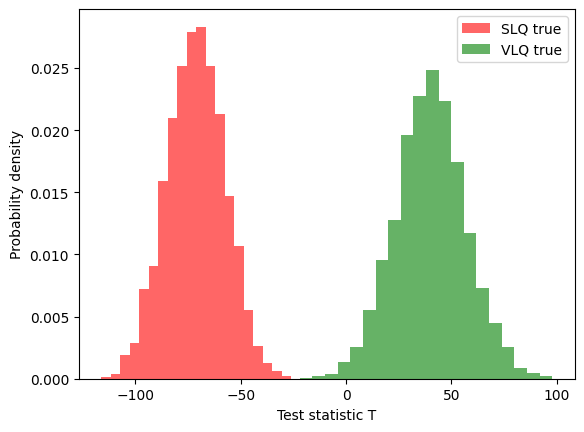

In [ ]:
mu_S = np.mean(T_SLQ)
mu_V = np.mean(T_VLQ)

sigma_S = np.std(T_SLQ)
sigma_V = np.std(T_VLQ)

Z = abs(mu_V - mu_S) / np.sqrt(sigma_S**2 + sigma_V**2)

print("Z distributions (gaussians) =", Z)

print('mean(T_SLQ) =', mu_S)
print('mean(T_VLQ) =', mu_V)

plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ true")
plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ true")

plt.xlabel("Test statistic T")
plt.ylabel("Probability density")
plt.legend()
plt.show()

T observed = 53.97961
mean(T_SLQ) = -71.28714
mean(T_VLQ) = 40.007294

Pseudo experimento compatible con VLQ
Z wrt SLQ = 9.113214
Z wrt VLQ = 0.8345459


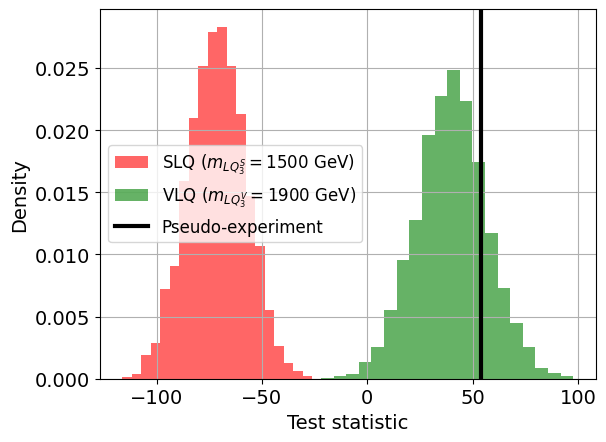

In [ ]:
N_B = np.random.poisson(B_expected)
N_S = np.random.poisson(S_expected)

mass = 1900
sample_B = events_SM[np.random.randint(len(events_SM), size=N_B)]
sample_S = events_VLQ[mass][np.random.randint(len(events_VLQ[mass]), size=N_S)]

sample_all = np.vstack([sample_B, sample_S])

scoresA = sample_all[:,0]
scoresB = sample_all[:,1]

T_obs = compute_test_statistic(scoresA, scoresB, threshold_A)

print("T observed =", T_obs)
print('mean(T_SLQ) =', mu_S)
print('mean(T_VLQ) =', mu_V)

print('')
if abs(T_obs - mu_S) < abs(T_obs - mu_V):
    print("Pseudo experimento compatible con SLQ")
else:
    print("Pseudo experimento compatible con VLQ")


Z_SLQ = (T_obs - mu_S) / sigma_S
Z_VLQ = (T_obs - mu_V) / sigma_V

print("Z wrt SLQ =", Z_SLQ)
print("Z wrt VLQ =", Z_VLQ)


plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label=r"SLQ ($m_{LQ_3^S}=1500$ GeV)")
plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label=r"VLQ ($m_{LQ_3^V}=1900$ GeV)")

plt.axvline(T_obs, color='black', lw=3, label="Pseudo-experiment")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Test statistic", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(loc='center left', fontsize=12)
plt.grid(True)
plt.savefig(mainfolder + 'saved-results/example-stat-T.pdf', bbox_inches='tight')
plt.show()

In [ ]:
p_SLQ = np.mean(np.array(T_SLQ) >= T_obs)
p_VLQ = np.mean(np.array(T_VLQ) <= T_obs)

print("p-value SLQ =", p_SLQ)
print("p-value VLQ =", p_VLQ)

p-value SLQ = 0.0
p-value VLQ = 0.8006


In [ ]:
print('Two-tailed') # Probability of a result more extreme in either direction.
print( "p-value SLQ =", 2 * stats.norm.sf(abs(Z_SLQ)) )
print( "p-value VLQ =", 2 * stats.norm.sf(abs(Z_VLQ)) )

print('\nRight-tailed') # Probability of a result greater than tobs
print( "p-value SLQ =", stats.norm.sf(Z_SLQ) )
print( "p-value VLQ =", stats.norm.sf(Z_VLQ) )

print('\nLeft-tailed') # Probability of a result less than tobs
print( "p-value SLQ =", stats.norm.cdf(Z_SLQ) )
print( "p-value VLQ =", stats.norm.cdf(Z_VLQ) )

Two-tailed
p-value SLQ = 7.997718860020988e-20
p-value VLQ = 0.4039734276745701

Right-tailed
p-value SLQ = 3.998859430010494e-20
p-value VLQ = 0.20198671383728506

Left-tailed
p-value SLQ = 1.0
p-value VLQ = 0.7980132861627149


In [ ]:
print('We will use the two-tailed')
print('\n Two-tailed    p=0.05 (0.025 per side)     -> 95% C.L.   -> Z=1.96')
print('\n One-tailed    p=0.05 (0.05 just one side) -> 95% C.L.   -> Z=1.645')

We will use the two-tailed

 Two-tailed    p=0.05 (0.025 per side)     -> 95% C.L.   -> Z=1.96

 One-tailed    p=0.05 (0.05 just one side) -> 95% C.L.   -> Z=1.645


### For all the masses

In [ ]:
# funcion para generar pseudo experimentos (da los scores de ambos clasificadores para ese pseudo)

def generate_pseudo(events_B, events_S, N_B, N_S):

    sample_B = events_B[np.random.randint(len(events_B), size=N_B)]
    sample_S = events_S[np.random.randint(len(events_S), size=N_S)]

    sample_all = np.vstack([sample_B, sample_S])

    scoresA = sample_all[:,0]
    scoresB = sample_all[:,1]

    return scoresA, scoresB

In [ ]:
B_expected = 45962

S_exp_SLQ = [round(fid_xsec_SLQ_14TeV(mmm, beta) * Lum) for mmm in m_SLQ]
S_exp_VLQ = [round(fid_xsec_VLQ_14TeV(mmm, beta) * Lum) for mmm in m_VLQ]

print('beta = ', beta)
print('\nB_expected: ', B_expected)
print('\nS_exp_SLQ: ', S_exp_SLQ, '   m =', m_SLQ)
print('S_exp_VLQ: ', S_exp_VLQ, '   m =', m_VLQ)
print('S_exp_both: ', S_exp_both)

beta =  0.5

B_expected:  45962

S_exp_SLQ:  [742, 419, 237, 137, 80, 46, 27, 16]    m = [1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900]
S_exp_VLQ:  [796, 466, 273, 163, 98, 59, 36, 22]    m = [1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300]
S_exp_both:  [np.float64(715.7083157794989), np.float64(415.46446800948), np.float64(240.22504729650277), np.float64(141.733642661406), np.float64(84.18804194702852), np.float64(48.835951997763644), np.float64(29.436025742910758), np.float64(17.55063184951355)]


#### Distribution of the statistic with only SLQ and only VLQ

In [ ]:
n_pseudo_TRUE = 1000
threshold_A = 0.95

In [ ]:
mu_S = []
mu_V = []

sigma_S = []
sigma_V = []

for S_it in range(len(S_exp_SLQ)):

    print("\n==========================")
    print("S_expected SLQ =", S_exp_SLQ[S_it])
    # print("S_expected VLQ =", S_exp_VLQ[S_it]) # same number of events

    # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
    mass_SLQ = m_SLQ[S_it]
    mass_VLQ = m_VLQ[S_it]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    for i in range(n_pseudo_TRUE):

        N_B = np.random.poisson(B_expected)
        N_S = np.random.poisson(S_exp_SLQ[S_it])

        scoresA, scoresB = generate_pseudo( events_SM, events_SLQ[mass_SLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)


        N_S = np.random.poisson(S_exp_SLQ[S_it]) # same number of events

        scoresA, scoresB = generate_pseudo( events_SM, events_VLQ[mass_VLQ], N_B, N_S )

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

        # Compute the Z of the distributions
    mu_S.append( np.mean(T_SLQ) )
    mu_V.append( np.mean(T_VLQ) )

    sigma_S.append( np.std(T_SLQ) )
    sigma_V.append( np.std(T_VLQ) )

print(mu_S)
print(mu_V)

print(sigma_S)
print(sigma_V)


S_expected SLQ = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV

S_expected SLQ = 419
mass_SLQ = 1300  GeV
mass_VLQ = 1700  GeV

S_expected SLQ = 237
mass_SLQ = 1400  GeV
mass_VLQ = 1800  GeV

S_expected SLQ = 137
mass_SLQ = 1500  GeV
mass_VLQ = 1900  GeV

S_expected SLQ = 80
mass_SLQ = 1600  GeV
mass_VLQ = 2000  GeV

S_expected SLQ = 46
mass_SLQ = 1700  GeV
mass_VLQ = 2100  GeV

S_expected SLQ = 27
mass_SLQ = 1800  GeV
mass_VLQ = 2200  GeV

S_expected SLQ = 16
mass_SLQ = 1900  GeV
mass_VLQ = 2300  GeV
[np.float32(-314.8582), np.float32(-187.21968), np.float32(-112.24484), np.float32(-72.42766), np.float32(-50.306973), np.float32(-38.149338), np.float32(-31.49379), np.float32(-27.96178)]
[np.float32(486.22714), np.float32(224.784), np.float32(99.796585), np.float32(39.70232), np.float32(8.197646), np.float32(-6.1297135), np.float32(-13.845172), np.float32(-17.376081)]
[np.float32(26.003477), np.float32(20.66743), np.float32(15.82232), np.float32(13.512912), np.float32(12.13875), np.flo

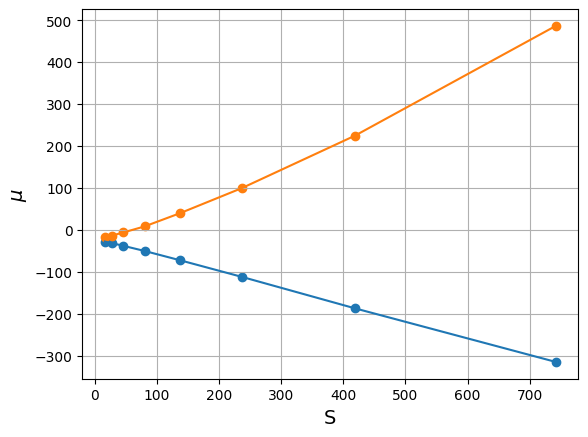

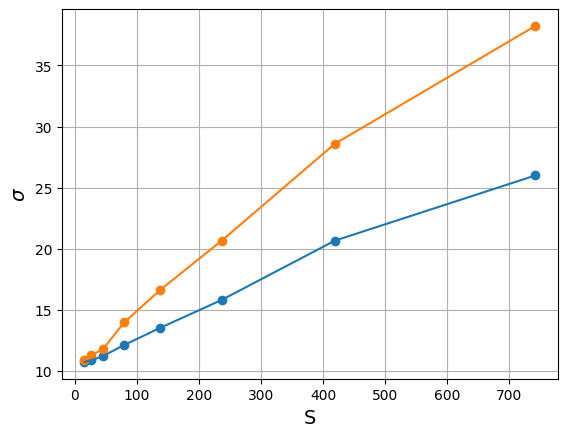

In [ ]:
f_mu_S = interp1d(S_exp_SLQ, mu_S, kind='linear', fill_value="extrapolate")
f_mu_V = interp1d(S_exp_SLQ, mu_V, kind='linear', fill_value="extrapolate")

f_sigma_S = interp1d(S_exp_SLQ, sigma_S, kind='linear', fill_value="extrapolate")
f_sigma_V = interp1d(S_exp_SLQ, sigma_V, kind='linear', fill_value="extrapolate")



S_plot = np.linspace(min(S_exp_SLQ), max(S_exp_SLQ), 100)



plt.scatter(S_exp_SLQ, mu_S, marker='o')
plt.plot(S_plot, f_mu_S(S_plot))
plt.scatter(S_exp_SLQ, mu_V, marker='o')
plt.plot(S_plot, f_mu_V(S_plot))

plt.xlabel("S", fontsize=14)
plt.ylabel(r"$\mu$", fontsize=14)

plt.grid()
plt.show()


plt.scatter(S_exp_SLQ, sigma_S, marker='o')
plt.plot(S_plot, f_sigma_S(S_plot))
plt.scatter(S_exp_SLQ, sigma_V, marker='o')
plt.plot(S_plot, f_sigma_V(S_plot))

plt.xlabel("S", fontsize=14)
plt.ylabel(r"$\sigma$", fontsize=14)

plt.grid()
plt.show()

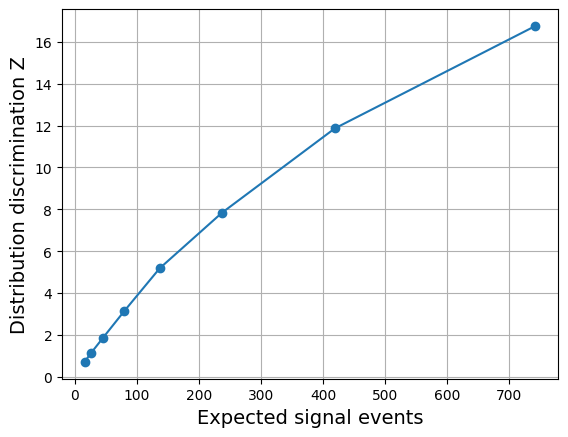

 Z:        5
 S:        131.87516253448675
 m_SLQ:    1508.990942921953  [GeV]
 m_VLQ:    1908.990942921953  [GeV]



In [ ]:
Z_threshold = 5

results_Z_gauss = []

for pair_it in range(len(mu_S)):
    Z = abs(mu_V[pair_it] - mu_S[pair_it]) / np.sqrt(sigma_S[pair_it]**2 + sigma_V[pair_it]**2)

    results_Z_gauss.append(Z)


plt.plot(S_exp_SLQ, results_Z_gauss, marker='o')

plt.xlabel("Expected signal events", fontsize=14)
plt.ylabel("Distribution discrimination Z", fontsize=14)

plt.grid()
plt.show()


#  interpolate
f_results_Z = interp1d(S_exp_SLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mSLQ = interp1d(m_SLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")
f_results_Z_mVLQ = interp1d(m_VLQ, results_Z_gauss, kind='linear', fill_value="extrapolate")


# find the S or the mass such that we get Z_threshold
S_threshold = fsolve(lambda x: f_results_Z(x) - Z_threshold,150)[0]
mSLQ_threshold = fsolve(lambda x: f_results_Z_mSLQ(x) - Z_threshold,1500)[0]
mVLQ_threshold = fsolve(lambda x: f_results_Z_mVLQ(x) - Z_threshold,1900)[0]

print(' Z:       ', Z_threshold)
print(' S:       ', S_threshold)
print(' m_SLQ:   ', mSLQ_threshold, ' [GeV]')
print(' m_VLQ:   ', mVLQ_threshold, ' [GeV]\n')

#### Prepare the data

##### To compute S_expected for each pseudo using the 1st classifier we need the PDFs

In [ ]:
# --- Clasificador A: SM vs LQ ---

# output of all the signal events
scoresA_S = xgb_clf.predict_proba( df_LQ_norm )[:, 1]



bins = np.linspace(0, 1, 30)

# normalized histograms of pure signal and pure background
hist_B, _ = np.histogram(scoresA_SM, bins=bins, density=True)
hist_S, _ = np.histogram(scoresA_S, bins=bins, density=True)


bin_width = bins[1] - bins[0]

pS = hist_S * bin_width
pB = hist_B * bin_width

##### to compute the closest mass/index/bechmark

In [ ]:
def search_bench(S_pseudo, S_list_means, S_list_std, masses_list=None):
    """ finds the index of the closest benchmark

    Inputs:
    -----------
    S_pseudo : float -> S computed or fitted (e.g. muS_fits_SLQ[i]).
    S_list_means : list/array -> S_mean_fit_both_NEW.
    S_list_std : list/array -> S_std_fit_both_NEW.
    masses_list : list/array (optional) -> masses_NEW.

    Outputs:
    --------
    if masses_list es None -> returns only the index
    if masses_list se incluye -> returns (index, closest mass).
    """
    # convert to array
    means = np.array(S_list_means)
    stds = np.array(S_list_std)

    # do not divide by 0
    stds = np.where(stds == 0, 1e-10, stds)

    # compute the distance to the means, weighted by the std
    z_scores = np.abs(S_pseudo - means) / stds

    # seach the closest index
    idx_min = np.argmin(z_scores)

    # if you also want the mass
    if masses_list is not None:
        best_mass = masses_list[idx_min]
        return idx_min, best_mass

    return idx_min

In [ ]:
S_TEST = 453

index_TEST = search_bench(S_TEST, S_mean_fit_both_NEW, S_std_fit_both_NEW )

print('S_TEST: ', S_TEST)
print('index: ', index_TEST)
print('S_fit: ', S_mean_fit_both_NEW[index_TEST])
print('S_fit_std: ', S_std_fit_both_NEW[index_TEST])
print('mass: ', masses_NEW[index_TEST])

S_TEST:  453
index:  20
S_fit:  463.706915648027
S_fit_std:  24.91658481866841
mass:  1280.0


In [ ]:
S_TEST = 453

index_TEST = search_bench(S_TEST, S_mean_fit_both, S_std_fit_both )

print('S_TEST: ', S_TEST)
print('index: ', index_TEST)
print('S_fit: ', S_mean_fit_both[index_TEST])
print('S_fit_std: ', S_std_fit_both[index_TEST])
print('mass: ', masses_SLQ[index_TEST])

S_TEST:  453
index:  3
S_fit:  415.8042220262091
S_fit_std:  23.675271637006066
mass:  1300


### Super loop

##### down


S_expected_SLQ = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV


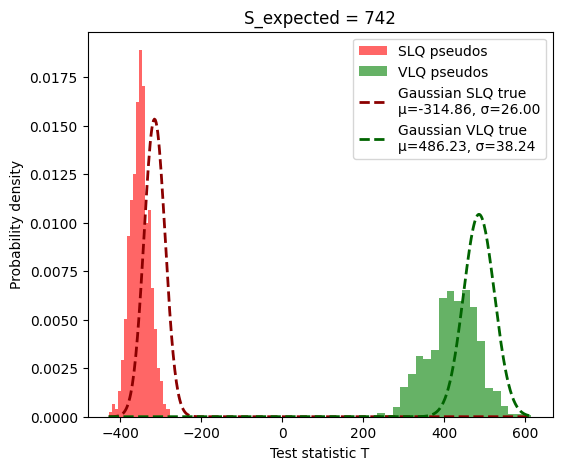

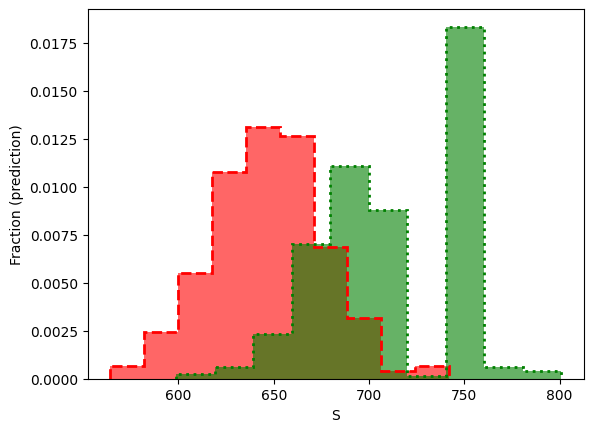

S mean SLQ:  647.2240914994625
S std SLQ:  29.541067700263824
S mean VLQ:  708.5448617938653
S std VLQ:  33.19716396330517


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.575
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.425

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.687
2 = both     : 0.0
3 = neither  : 0.313

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.14
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.86

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.765
2 = both     : 0.0
3 = neither  : 0.235

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fracti

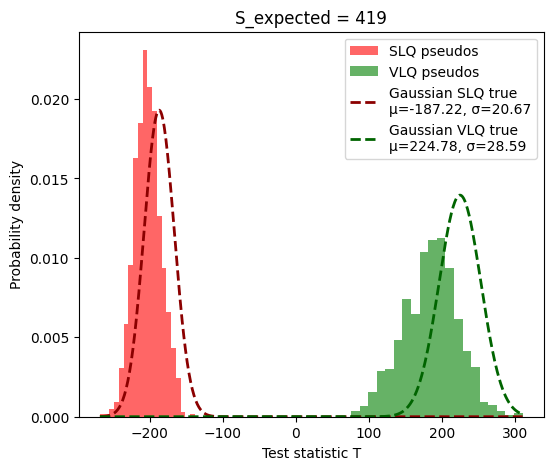

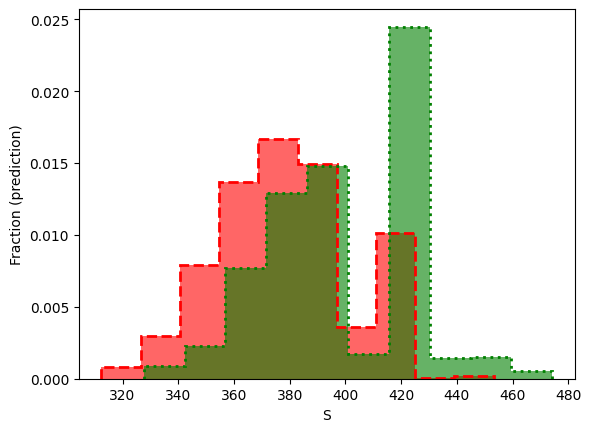

S mean SLQ:  378.3708725942006
S std SLQ:  24.042378134404224
S mean VLQ:  397.76930044985716
S std VLQ:  24.67113195764173


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.893
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.107

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.69
2 = both     : 0.0
3 = neither  : 0.31

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.611
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.389

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.839
2 = both     : 0.0
3 = neither  : 0.161

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fract

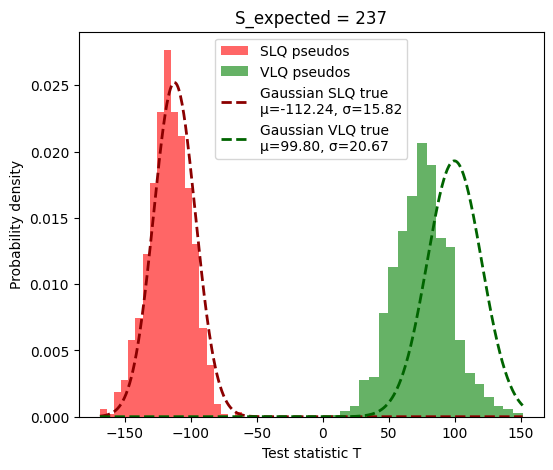

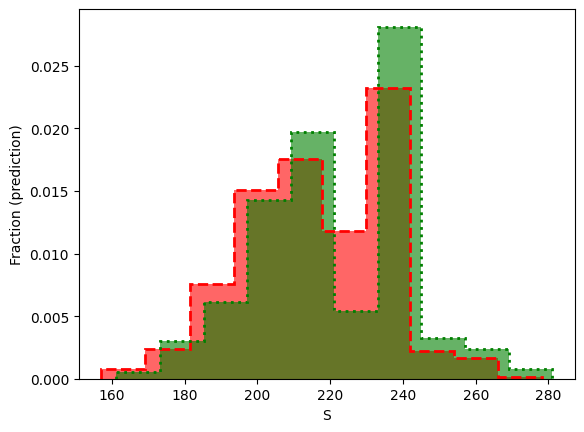

S mean SLQ:  216.67498797081942
S std SLQ:  20.093553419230147
S mean VLQ:  221.15234855255088
S std VLQ:  20.04840927451291


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.896
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.104

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.768
2 = both     : 0.0
3 = neither  : 0.232

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.874
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.126

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.897
2 = both     : 0.0
3 = neither  : 0.103

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fr

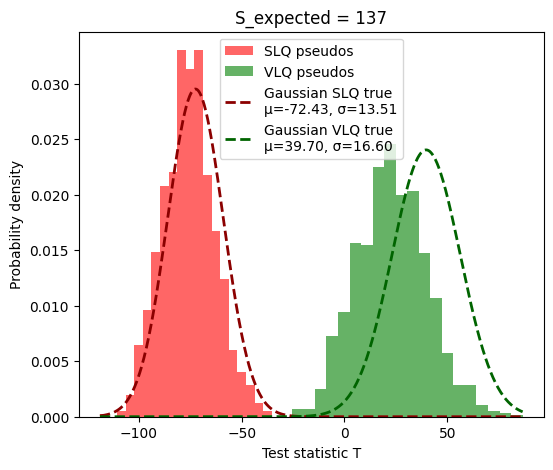

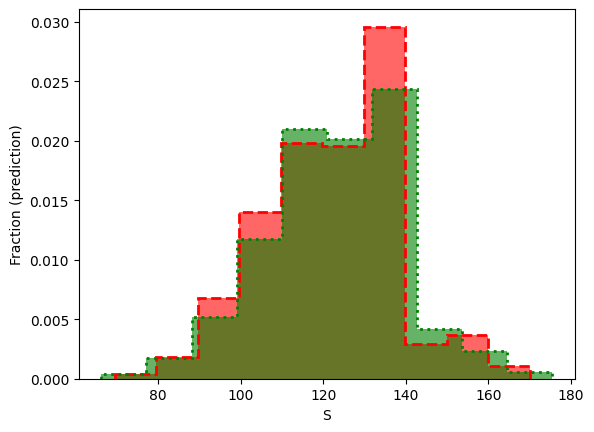

S mean SLQ:  122.85406005919101
S std SLQ:  16.574423382559353
S mean VLQ:  123.09820159098683
S std VLQ:  16.53212725345538


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.879
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.121

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.858
2 = both     : 0.0
3 = neither  : 0.142

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.892
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.108

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.924
2 = both     : 0.0
3 = neither  : 0.076

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fr

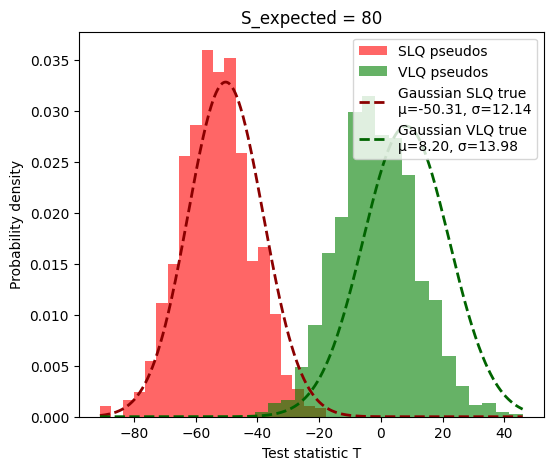

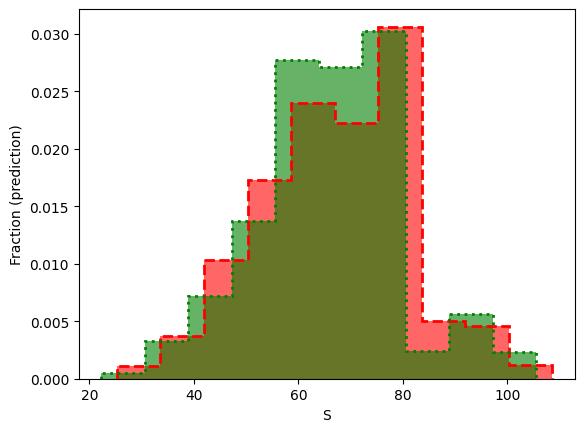

S mean SLQ:  67.68584006260491
S std SLQ:  14.453579066949866
S mean VLQ:  66.8378220880797
S std VLQ:  14.387368910245796


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.879
1 = VLQ only : 0.0
2 = both     : 0.012
3 = neither  : 0.109

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.012
1 = VLQ only : 0.877
2 = both     : 0.069
3 = neither  : 0.042

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.898
1 = VLQ only : 0.002
2 = both     : 0.007
3 = neither  : 0.093

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.019
1 = VLQ only : 0.909
2 = both     : 0.048
3 = neither  : 0.024

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Class

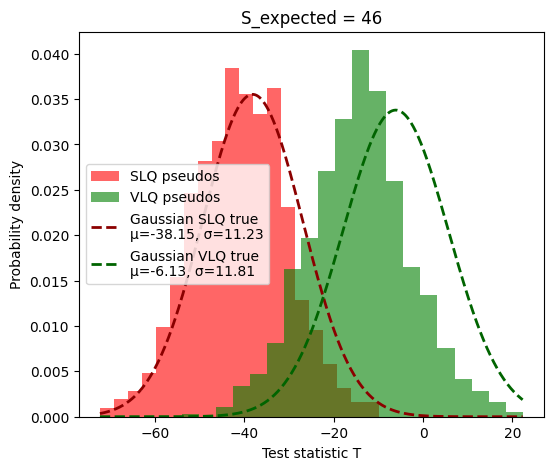

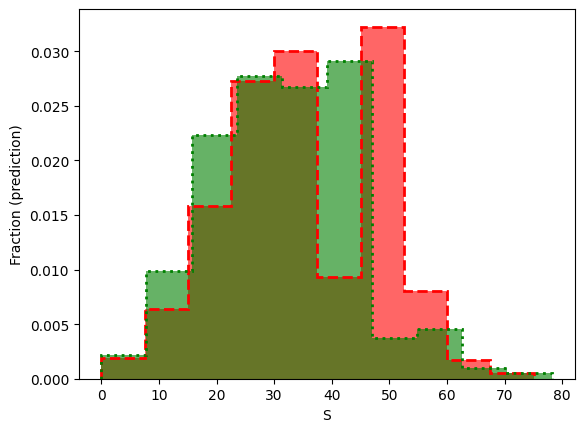

S mean SLQ:  34.26184965277728
S std SLQ:  12.90300024246231
S mean VLQ:  32.44159157158222
S std VLQ:  13.208332200843785


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.65
1 = VLQ only : 0.002
2 = both     : 0.264
3 = neither  : 0.084

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.045
1 = VLQ only : 0.385
2 = both     : 0.554
3 = neither  : 0.016

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.661
1 = VLQ only : 0.005
2 = both     : 0.25
3 = neither  : 0.084

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.05
1 = VLQ only : 0.381
2 = both     : 0.552
3 = neither  : 0.017

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classi

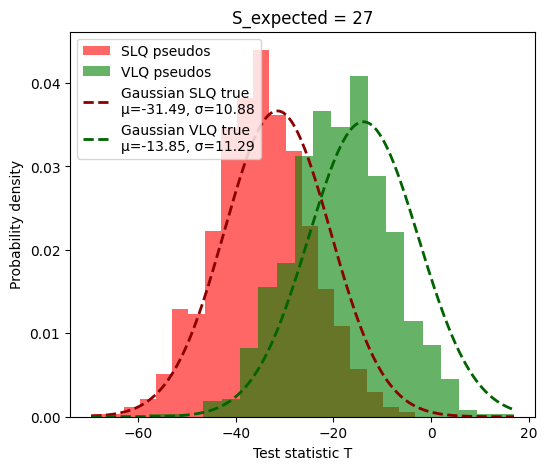

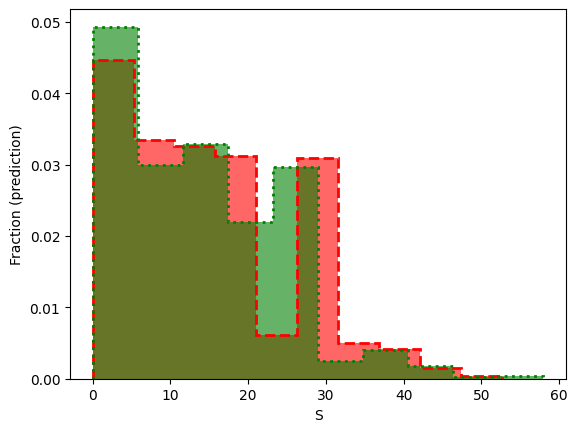

S mean SLQ:  14.350743502854137
S std SLQ:  10.671849092042947
S mean VLQ:  13.830366156860611
S std VLQ:  10.765491191411467


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.331
1 = VLQ only : 0.003
2 = both     : 0.609
3 = neither  : 0.057

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.032
1 = VLQ only : 0.148
2 = both     : 0.813
3 = neither  : 0.007

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.257
1 = VLQ only : 0.002
2 = both     : 0.665
3 = neither  : 0.076

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.022
1 = VLQ only : 0.094
2 = both     : 0.858
3 = neither  : 0.026

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ


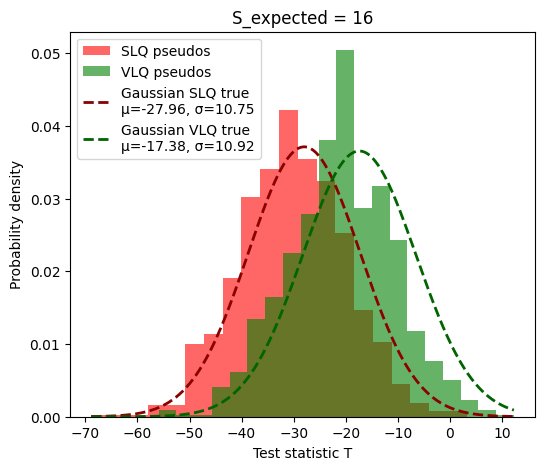

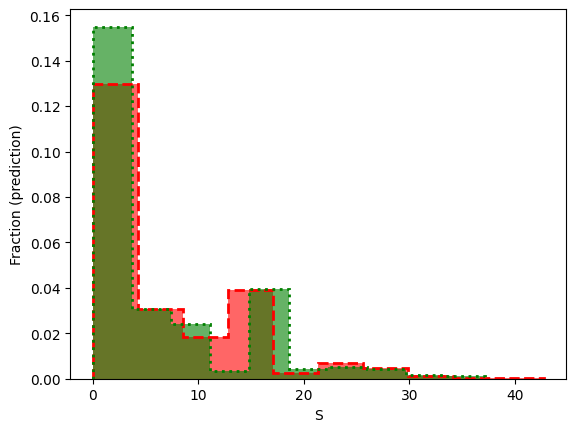

S mean SLQ:  6.348352332751186
S std SLQ:  7.951552548025221
S mean VLQ:  5.750254123161525
S std VLQ:  7.708359800941789


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.197
1 = VLQ only : 0.01
2 = both     : 0.77
3 = neither  : 0.023

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.044
1 = VLQ only : 0.079
2 = both     : 0.867
3 = neither  : 0.01

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.087
1 = VLQ only : 0.004
2 = both     : 0.85
3 = neither  : 0.059

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.027
1 = VLQ only : 0.018
2 = both     : 0.922
3 = neither  : 0.033

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classifi

In [ ]:
Z_threshold = 1.96

n_pseudo = 1000

# benchmarks
classification_SLQ_BPOK = []
classification_VLQ_BPOK = []

# interpolate
classification_SLQ_inter = []
classification_VLQ_inter = []

# previously known PDFs
classification_SLQ_prev = []
classification_VLQ_prev = []


Z_SLQ_BPOK = []
Z_VLQ_BPOK = []

Z_SLQ_inter = []
Z_VLQ_inter = []

Z_SLQ_prev = []
Z_VLQ_prev = []


mu_TSLQ = []
std_TSLQ = []
mu_TVLQ = []
std_TVLQ = []



for ii_S, S_exp in enumerate(S_exp_SLQ):

    print("\n==========================")

    print("S_expected_SLQ =", S_exp_SLQ[ii_S])
    # print("S_expected_VLQ =", S_exp_VLQ[ii_S]) # same number of events


    # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
    mass_SLQ = m_SLQ[ii_S]
    mass_VLQ = m_VLQ[ii_S]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    # compute the number of events
    muS_fits_SLQ = []
    muS_fits_VLQ = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM_down[:,0]), N_B)

        scoresA_B = events_SM_down[:,0][idx_B]
        scoresB_B = events_SM_down[:,1][idx_B]



        ###########
        # FOR SLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S])

        # indices of the events
        idx_S = np.random.choice(len(events_SLQ_down[mass_SLQ][:,0]), N_S)

        scoresA_S = events_SLQ_down[mass_SLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_SLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_SLQ_down_norm[mass_SLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)




        ###########
        # FOR VLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S]) # same number of events

        # indices of the events
        idx_S = np.random.choice(len(events_VLQ_down[mass_VLQ][:,0]), N_S)

        scoresA_S = events_VLQ_down[mass_VLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_VLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_V = df_VLQ_down_norm[mass_VLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_V = np.column_stack([X_pseudo_V, np.full(len(X_pseudo_V), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_V)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

    # Compute the characteristics of the psedo-experiment T distributions
    mu_TSLQ.append( np.mean(T_SLQ) )
    mu_TVLQ.append( np.mean(T_VLQ) )

    std_TSLQ.append( np.std(T_SLQ) )
    std_TVLQ.append( np.std(T_VLQ) )




    # rango común para plotear
    xmin = min(np.min(T_SLQ), np.min(T_VLQ))
    xmax = max(np.max(T_SLQ), np.max(T_VLQ))
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
    gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


    # plot gaussian PDFs + pseudo-experiments (of the same sector) distributions
    plt.figure(figsize=(6,5))

    plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
    plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

    # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    plt.hist(muS_fits_SLQ, bins=10, histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
    plt.hist(muS_fits_SLQ, bins=10, color='red', alpha=0.6, density=True)
    plt.hist(muS_fits_VLQ, bins=10, histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
    plt.hist(muS_fits_VLQ, bins=10, color='green', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_SLQ))
    print('S std SLQ: ', np.std(muS_fits_SLQ))
    print('S mean VLQ: ', np.mean(muS_fits_VLQ))
    print('S std VLQ: ', np.std(muS_fits_VLQ))
    print('')


    # COMPARING WITH DISCRETE MASS EXAMPLES (following S)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_BPOK_step = []
    Z_VLQ_BPOK_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        index_pseudo = search_bench(muS_fits_SLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_SLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        index_pseudo = search_bench(muS_fits_VLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_VLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_BPOK.append(np.array(Z_SLQ_BPOK_step))
    Z_VLQ_BPOK.append(np.array(Z_VLQ_BPOK_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH DISCRETE MASS EXAMPLES (following S) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_BPOK.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_BPOK.append(pred_counts_VLQ)





    # COMPARING WITH CONTINUOUS MASSES (interpolation)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_inter_step = []
    Z_VLQ_inter_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_SLQ[i])) / f_sigma_S(muS_fits_SLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_SLQ[i])) / f_sigma_V(muS_fits_SLQ[i])

        Z_SLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_VLQ[i])) / f_sigma_S(muS_fits_VLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_VLQ[i])) / f_sigma_V(muS_fits_VLQ[i])

        Z_VLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_inter.append(np.array(Z_SLQ_inter_step))
    Z_VLQ_inter.append(np.array(Z_VLQ_inter_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH CONTINUOUS MASSES (interpolation) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_inter.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_inter.append(pred_counts_VLQ)





    # COMPARING WITH THE PREVIOUSLY KNOWN PDF

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_prev_step = []
    Z_VLQ_prev_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_SLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_VLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_prev.append(np.array(Z_SLQ_prev_step))
    Z_VLQ_prev.append(np.array(Z_VLQ_prev_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH THE PREVIOUSLY KNOWN PDF ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_prev.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_prev.append(pred_counts_VLQ)


In [ ]:
# takes all Z (1 per pseudo) and computes the median and percentiles
def Z_processor(lista_Z, select):
    """computes the median and error (percentiles 16 y 84)
    select = 1 ---> SLQ (true) vs VLQ
    select = 0 ---> VLQ (true) vs SLQ
    """
    medians = []
    err_inf = []
    err_sup = []

    for z_matriz in lista_Z:
        z_valores = z_matriz[:, select]
        med = np.median(z_valores)
        p16 = np.percentile(z_valores, 16)
        p84 = np.percentile(z_valores, 84)

        medians.append(med)
        err_inf.append(med - p16)  # percentile
        err_sup.append(p84 - med)  # percentile

    return np.array(medians), [np.array(err_inf), np.array(err_sup)]



# Interpolate to find Z=5
def find_mass(mass_array, z_med, err_list, z_target=5.0):
    """Interpolate the mass and find the error, 1-sigma"""
    if np.max(z_med) < z_target and np.min(z_med) < z_target:
        return None, None, None # Z is not in this range

    # mass grid
    grid_masas = np.linspace(mass_array.min(), mass_array.max(), 1000)

    # curves
    z_sup_valores = z_med + err_list[1] # Median + err_sup (percentil 84)
    z_inf_valores = z_med - err_list[0] # Median - err_inf (percentil 16)

    f_med = interp1d(mass_array, z_med, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_sup = interp1d(mass_array, z_sup_valores, kind='linear', bounds_error=False, fill_value="extrapolate")
    f_inf = interp1d(mass_array, z_inf_valores, kind='linear', bounds_error=False, fill_value="extrapolate")

    # search for Z = z_target
    m5_central = grid_masas[np.argmin(np.abs(f_med(grid_masas) - z_target))]
    m5_inf     = grid_masas[np.argmin(np.abs(f_inf(grid_masas) - z_target))]
    m5_sup     = grid_masas[np.argmin(np.abs(f_sup(grid_masas) - z_target))]

    return m5_central, m5_inf, m5_sup

In [ ]:


# Compute
z_BPOK_SLQ, err_BPOK_SLQ = Z_processor(Z_SLQ_BPOK, select=1)
z_BPOK_VLQ, err_BPOK_VLQ = Z_processor(Z_VLQ_BPOK, select=0)
z_inter_SLQ, err_inter_SLQ = Z_processor(Z_SLQ_inter, select=1)
z_inter_VLQ, err_inter_VLQ = Z_processor(Z_VLQ_inter, select=0)
z_prev_SLQ, err_prev_SLQ = Z_processor(Z_SLQ_prev, select=1)
z_prev_VLQ, err_prev_VLQ = Z_processor(Z_VLQ_prev, select=0)



In [ ]:
class_SLQ_BPOK_array = np.array(classification_SLQ_BPOK) # Forma (N, 4)
class_VLQ_BPOK_array = np.array(classification_VLQ_BPOK) # Forma (N, 4)

class_SLQ_inter_array = np.array(classification_SLQ_inter) # Forma (N, 4)
class_VLQ_inter_array = np.array(classification_VLQ_inter) # Forma (N, 4)

class_SLQ_prev_array = np.array(classification_SLQ_prev) # Forma (N, 4)
class_VLQ_prev_array = np.array(classification_VLQ_prev) # Forma (N, 4)

# SAVE

file_path = mainfolder + 'saved-results/vs14TeV_err_beta05_down.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    S_expected_SLQ[2:],
    m_SLQ,
    m_VLQ,
    mu_S,
    sigma_S,
    mu_V,
    sigma_V,
    mu_TSLQ,
    std_TSLQ,
    mu_TVLQ,
    std_TVLQ,
    class_SLQ_BPOK_array,
    class_VLQ_BPOK_array,
    class_SLQ_inter_array,
    class_VLQ_inter_array,
    class_SLQ_prev_array,
    class_VLQ_prev_array,
    z_BPOK_SLQ,
    err_BPOK_SLQ[0],
    err_BPOK_SLQ[1],
    z_BPOK_VLQ,
    err_BPOK_VLQ[0],
    err_BPOK_VLQ[1],
    z_inter_SLQ,
    err_inter_SLQ[0],
    err_inter_SLQ[1],
    z_inter_VLQ,
    err_inter_VLQ[0],
    err_inter_VLQ[1],
    z_prev_SLQ,
    err_prev_SLQ[0],
    err_prev_SLQ[1],
    z_prev_VLQ,
    err_prev_VLQ[0],
    err_prev_VLQ[1],
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# S_expected mass_list_SLQ mass_list_SLQ mu_S sigma_S mu_V sigma_V mu_TSLQ std_TSLQ mu_TVLQ std_TVLQ classification_SLQ classification_VLQ',
           comments='')

print(f"Data saved to: {file_path}")

Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/vs14TeV_err_beta05_down.txt


##### up


S_expected_SLQ = 742
mass_SLQ = 1200  GeV
mass_VLQ = 1600  GeV


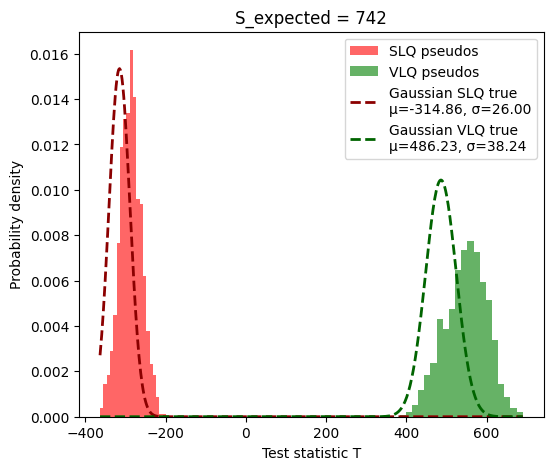

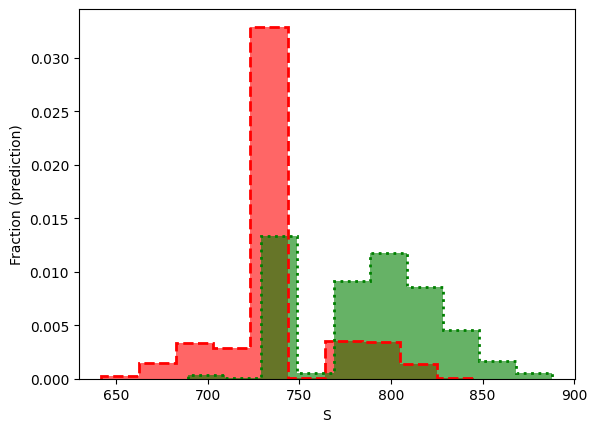

S mean SLQ:  742.6183040277724
S std SLQ:  28.254663995929736
S mean VLQ:  788.5983829192012
S std VLQ:  35.69647595255217


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.883
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.117

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.399
2 = both     : 0.0
3 = neither  : 0.601

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.781
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.219

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.918
2 = both     : 0.0
3 = neither  : 0.082

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification frac

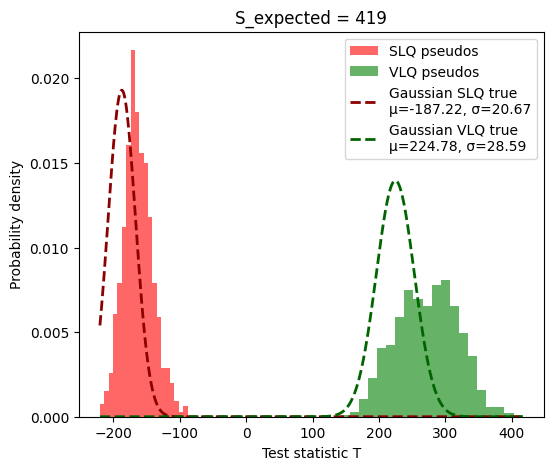

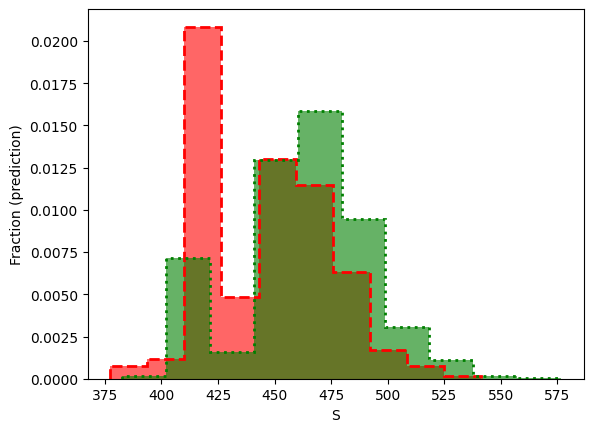

S mean SLQ:  445.869478350182
S std SLQ:  27.088494966159985
S mean VLQ:  464.11680469080386
S std VLQ:  27.025926777771964


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.795
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.205

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.524
2 = both     : 0.0
3 = neither  : 0.476

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.627
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.373

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.913
2 = both     : 0.0
3 = neither  : 0.087

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fra

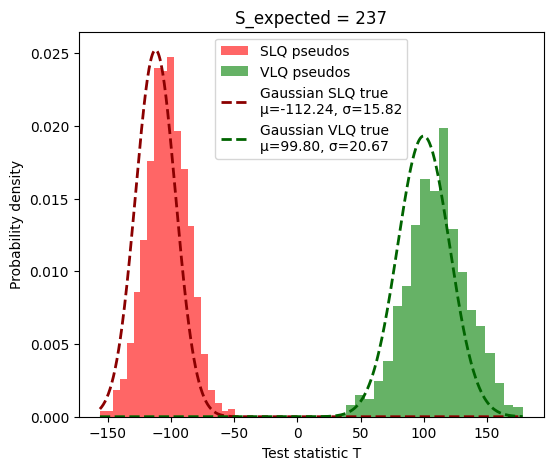

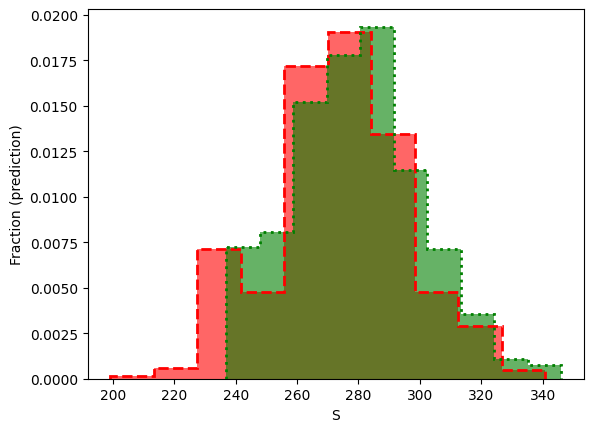

S mean SLQ:  273.9189432366624
S std SLQ:  21.621057477363525
S mean VLQ:  278.80138910007213
S std VLQ:  21.392397026496454


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.879
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.121

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.856
2 = both     : 0.0
3 = neither  : 0.144

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.689
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.311

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.87
2 = both     : 0.0
3 = neither  : 0.13

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification frac

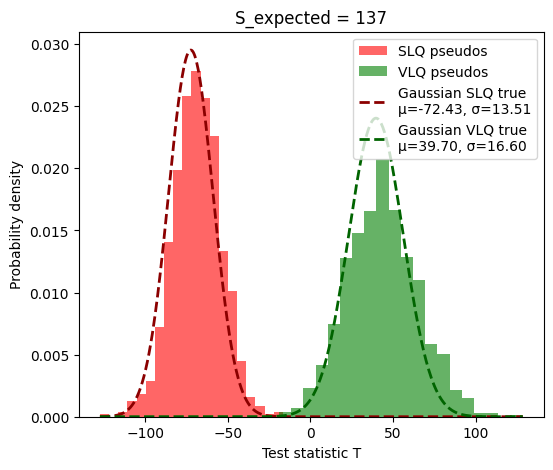

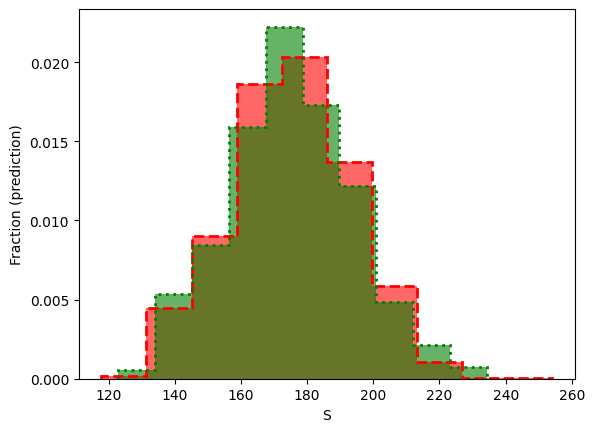

S mean SLQ:  175.09956049638066
S std SLQ:  18.750915093477147
S mean VLQ:  175.15670947128453
S std VLQ:  19.32333710366112


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.722
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.278

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.807
2 = both     : 0.0
3 = neither  : 0.193

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.726
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.274

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.0
1 = VLQ only : 0.814
2 = both     : 0.0
3 = neither  : 0.186

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classification fr

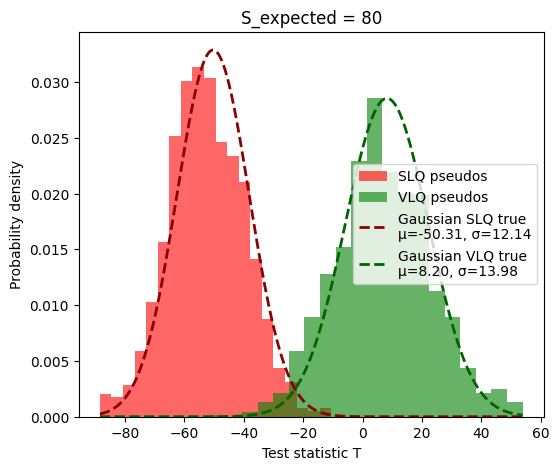

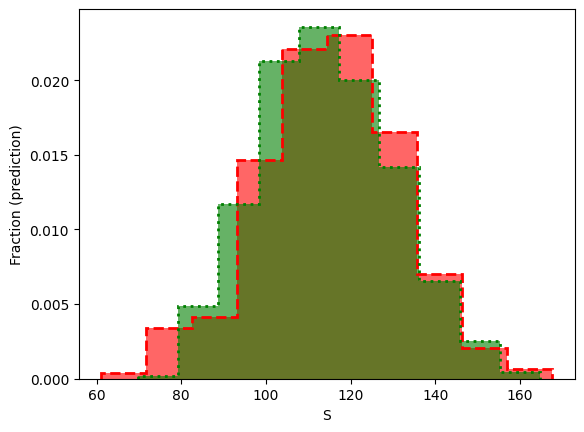

S mean SLQ:  115.23532759294027
S std SLQ:  16.61390367551358
S mean VLQ:  114.27130968441911
S std VLQ:  16.131557713064648


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.762
1 = VLQ only : 0.0
2 = both     : 0.001
3 = neither  : 0.237

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.009
1 = VLQ only : 0.672
2 = both     : 0.0
3 = neither  : 0.319

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.835
1 = VLQ only : 0.0
2 = both     : 0.0
3 = neither  : 0.165

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.005
1 = VLQ only : 0.765
2 = both     : 0.0
3 = neither  : 0.23

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Classificati

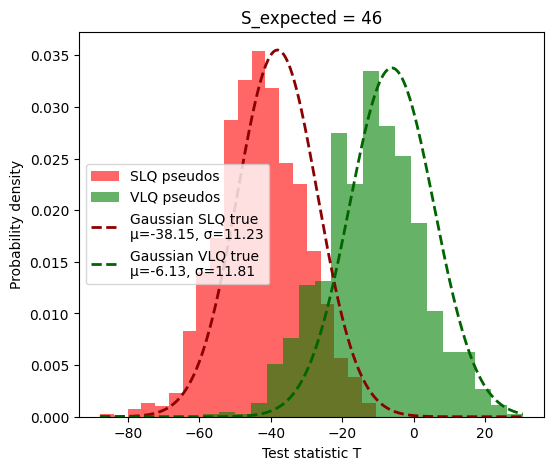

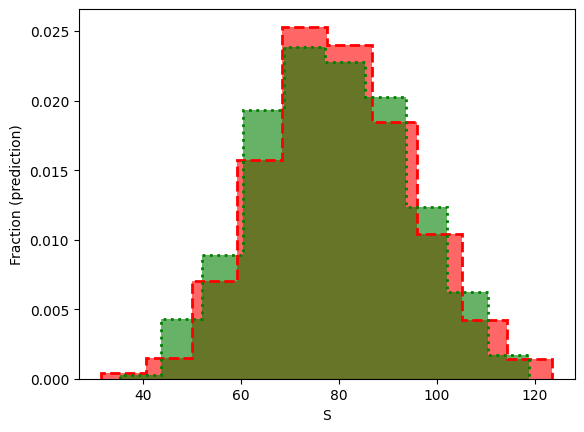

S mean SLQ:  79.7853924716914
S std SLQ:  15.111296341202614
S mean VLQ:  78.59901359144095
S std VLQ:  15.190379128691093


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.869
1 = VLQ only : 0.009
2 = both     : 0.011
3 = neither  : 0.111

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.112
1 = VLQ only : 0.642
2 = both     : 0.064
3 = neither  : 0.182

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.873
1 = VLQ only : 0.021
2 = both     : 0.003
3 = neither  : 0.103

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.127
1 = VLQ only : 0.667
2 = both     : 0.042
3 = neither  : 0.164

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Cla

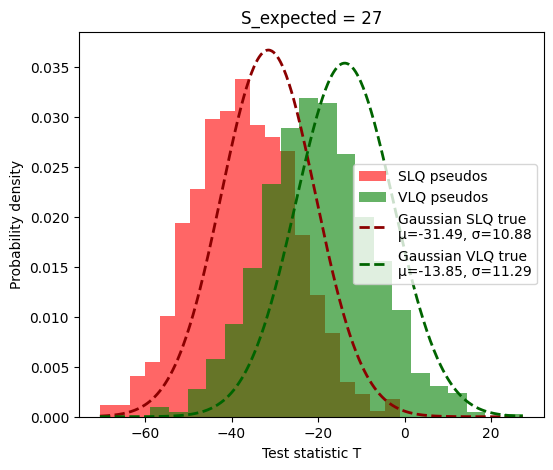

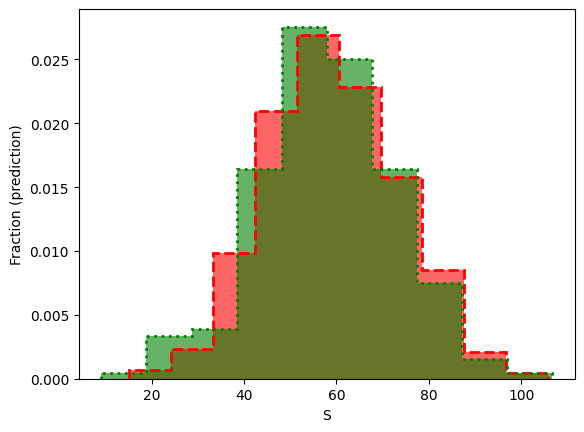

S mean SLQ:  59.159097070568755
S std SLQ:  14.334123703693228
S mean VLQ:  58.045635053052365
S std VLQ:  14.344061049283471


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.735
1 = VLQ only : 0.042
2 = both     : 0.151
3 = neither  : 0.072

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.238
1 = VLQ only : 0.38
2 = both     : 0.288
3 = neither  : 0.094

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.791
1 = VLQ only : 0.059
2 = both     : 0.115
3 = neither  : 0.035

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.288
1 = VLQ only : 0.445
2 = both     : 0.231
3 = neither  : 0.036

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
C

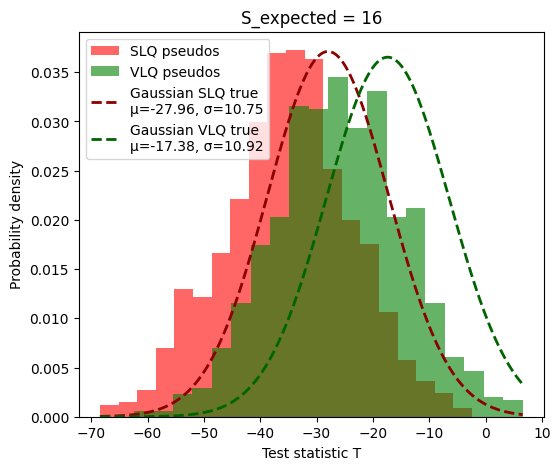

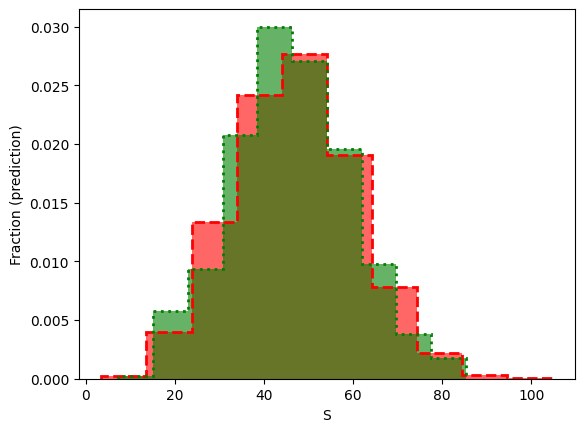

S mean SLQ:  46.866660733239115
S std SLQ:  13.787660630063378
S mean VLQ:  46.02842788993114
S std VLQ:  13.689085104274064


------
 COMPARING WITH DISCRETE MASS EXAMPLES (following S) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.636
1 = VLQ only : 0.042
2 = both     : 0.282
3 = neither  : 0.04

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.34
1 = VLQ only : 0.188
2 = both     : 0.444
3 = neither  : 0.028

------
 COMPARING WITH CONTINUOUS MASSES (interpolation) 
TESTING SLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.665
1 = VLQ only : 0.055
2 = both     : 0.258
3 = neither  : 0.022

TESTING VLQ
Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)
0 = SLQ only : 0.367
1 = VLQ only : 0.214
2 = both     : 0.413
3 = neither  : 0.006

------
 COMPARING WITH THE PREVIOUSLY KNOWN PDF 
TESTING SLQ
Cla

In [ ]:
Z_threshold = 1.96

n_pseudo = 1000

# benchmarks
classification_SLQ_BPOK = []
classification_VLQ_BPOK = []

# interpolate
classification_SLQ_inter = []
classification_VLQ_inter = []

# previously known PDFs
classification_SLQ_prev = []
classification_VLQ_prev = []


Z_SLQ_BPOK = []
Z_VLQ_BPOK = []

Z_SLQ_inter = []
Z_VLQ_inter = []

Z_SLQ_prev = []
Z_VLQ_prev = []


mu_TSLQ = []
std_TSLQ = []
mu_TVLQ = []
std_TVLQ = []



for ii_S, S_exp in enumerate(S_exp_SLQ):

    print("\n==========================")

    print("S_expected_SLQ =", S_exp_SLQ[ii_S])
    # print("S_expected_VLQ =", S_exp_VLQ[ii_S]) # same number of events


    # dado un S, le asigna la masa (del SLQ o VLQ) correspondiente
    mass_SLQ = m_SLQ[ii_S]
    mass_VLQ = m_VLQ[ii_S]
    print("mass_SLQ =", mass_SLQ, " GeV")
    print("mass_VLQ =", mass_VLQ, " GeV")


    # computamos el T statistic para todos los pseudo
    T_SLQ = []
    T_VLQ = []

    # compute the number of events
    muS_fits_SLQ = []
    muS_fits_VLQ = []


    for i in range(n_pseudo):

        N_B = np.random.poisson(B_expected)

        # indices of the events
        idx_B = np.random.choice(len(events_SM_up[:,0]), N_B)

        scoresA_B = events_SM_up[:,0][idx_B]
        scoresB_B = events_SM_up[:,1][idx_B]



        ###########
        # FOR SLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S])

        # indices of the events
        idx_S = np.random.choice(len(events_SLQ_up[mass_SLQ][:,0]), N_S)

        scoresA_S = events_SLQ_up[mass_SLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_SLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_S = df_SLQ_up_norm[mass_SLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_S = np.column_stack([X_pseudo_S, np.full(len(X_pseudo_S), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_S)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_SLQ.append(T)




        ###########
        # FOR VLQ #
        ###########

        N_S = np.random.poisson(S_exp_SLQ[ii_S]) # same number of events

        # indices of the events
        idx_S = np.random.choice(len(events_VLQ_up[mass_VLQ][:,0]), N_S)

        scoresA_S = events_VLQ_up[mass_VLQ][:,0][idx_S]


        data_scores = np.concatenate([scoresA_B, scoresA_S])

        hist_data, _ = np.histogram(data_scores, bins=bins)

        # 2) Define likelihood for this pseudo (gotta do it for the minimizer)
        def neg_logL(params):
            mu_S, mu_B = params

            lambda_i = mu_S * pS + mu_B * pB
            lambda_i = np.clip(lambda_i, 1e-10, None)

            return -np.sum(hist_data * np.log(lambda_i) - lambda_i)

        # 3) Minimizar
        result = minimize(
            neg_logL,
            x0=[S_exp, B_expected],
            bounds=[(0, None), (0, None)]
        )

        muS_fit, muB_fit = result.x

        muS_fits_VLQ.append(muS_fit)


        # the pseudo exp
        X_pseudo_V = df_VLQ_up_norm[mass_VLQ].loc[idx_S].values
        # add the S fitted
        X_pseudo_V = np.column_stack([X_pseudo_V, np.full(len(X_pseudo_V), muS_fit)])

        scoresB_S = classifier_spin.predict_proba(X_pseudo_V)[:,1]


        scoresA = np.concatenate([scoresA_B, scoresA_S])
        scoresB = np.concatenate([scoresB_B, scoresB_S])

        T = compute_test_statistic(scoresA, scoresB, threshold_A)

        T_VLQ.append(T)

    # Compute the characteristics of the psedo-experiment T distributions
    mu_TSLQ.append( np.mean(T_SLQ) )
    mu_TVLQ.append( np.mean(T_VLQ) )

    std_TSLQ.append( np.std(T_SLQ) )
    std_TVLQ.append( np.std(T_VLQ) )




    # rango común para plotear
    xmin = min(np.min(T_SLQ), np.min(T_VLQ))
    xmax = max(np.max(T_SLQ), np.max(T_VLQ))
    x = np.linspace(xmin, xmax, 500)

    # gaussianas
    gauss_S = (1/(sigma_S[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_S[ii_S])**2 / (2*sigma_S[ii_S]**2))
    gauss_V = (1/(sigma_V[ii_S]*np.sqrt(2*np.pi))) * np.exp(-(x - mu_V[ii_S])**2 / (2*sigma_V[ii_S]**2))


    # plot gaussian PDFs + pseudo-experiments (of the same sector) distributions
    plt.figure(figsize=(6,5))

    plt.hist(T_SLQ, bins=20, density=True, color='red', alpha=0.6, label="SLQ pseudos")
    plt.hist(T_VLQ, bins=20, density=True, color='green', alpha=0.6, label="VLQ pseudos")

    # gaussianas
    plt.plot(x, gauss_S, color='darkred', linewidth=2, linestyle='--', label=f"Gaussian SLQ true\nμ={mu_S[ii_S]:.2f}, σ={sigma_S[ii_S]:.2f}")
    plt.plot(x, gauss_V, color='darkgreen', linewidth=2, linestyle='--', label=f"Gaussian VLQ true\nμ={mu_V[ii_S]:.2f}, σ={sigma_V[ii_S]:.2f}")

    plt.xlabel("Test statistic T")
    plt.ylabel("Probability density")
    plt.title(f"S_expected = {S_exp}")
    plt.legend()

    plt.show()


    plt.hist(muS_fits_SLQ, bins=10, histtype='step', linestyle='--', edgecolor='red', linewidth=2, density=True)
    plt.hist(muS_fits_SLQ, bins=10, color='red', alpha=0.6, density=True)
    plt.hist(muS_fits_VLQ, bins=10, histtype='step', linestyle=':', edgecolor='green', linewidth=2, density=True)
    plt.hist(muS_fits_VLQ, bins=10, color='green', alpha=0.6, density=True)
    plt.xlabel("S")
    plt.ylabel("Fraction (prediction)")
    plt.show()

    print('S mean SLQ: ', np.mean(muS_fits_SLQ))
    print('S std SLQ: ', np.std(muS_fits_SLQ))
    print('S mean VLQ: ', np.mean(muS_fits_VLQ))
    print('S std VLQ: ', np.std(muS_fits_VLQ))
    print('')


    # COMPARING WITH DISCRETE MASS EXAMPLES (following S)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_BPOK_step = []
    Z_VLQ_BPOK_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        index_pseudo = search_bench(muS_fits_SLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_SLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        index_pseudo = search_bench(muS_fits_VLQ[i], S_mean_fit_both, S_std_fit_both )

        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(S_mean_fit_both[index_pseudo])) / f_sigma_S(S_mean_fit_both[index_pseudo])
        Z_VLQ_val = abs(T_obs - f_mu_V(S_mean_fit_both[index_pseudo])) / f_sigma_V(S_mean_fit_both[index_pseudo])

        Z_VLQ_BPOK_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_BPOK.append(np.array(Z_SLQ_BPOK_step))
    Z_VLQ_BPOK.append(np.array(Z_VLQ_BPOK_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH DISCRETE MASS EXAMPLES (following S) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_BPOK.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_BPOK.append(pred_counts_VLQ)





    # COMPARING WITH CONTINUOUS MASSES (interpolation)

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_inter_step = []
    Z_VLQ_inter_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_SLQ[i])) / f_sigma_S(muS_fits_SLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_SLQ[i])) / f_sigma_V(muS_fits_SLQ[i])

        Z_SLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - f_mu_S(muS_fits_VLQ[i])) / f_sigma_S(muS_fits_VLQ[i])
        Z_VLQ_val = abs(T_obs - f_mu_V(muS_fits_VLQ[i])) / f_sigma_V(muS_fits_VLQ[i])

        Z_VLQ_inter_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_inter.append(np.array(Z_SLQ_inter_step))
    Z_VLQ_inter.append(np.array(Z_VLQ_inter_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH CONTINUOUS MASSES (interpolation) ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_inter.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_inter.append(pred_counts_VLQ)





    # COMPARING WITH THE PREVIOUSLY KNOWN PDF

    # Vamos a clasificar cada pseudo
    # 0: SLQ
    # 1: VLQ
    # 2: compatible con ambos
    # 3: incompatible con ambos
    pred_counts_SLQ = [0,0,0,0]
    pred_counts_VLQ = [0,0,0,0]

    Z_SLQ_prev_step = []
    Z_VLQ_prev_step = []

    for i in range(n_pseudo):

        # TRUE: SLQ
        T_obs = T_SLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_SLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_SLQ[pred] += 1


        # TRUE: VLQ
        T_obs = T_VLQ[i]

        Z_SLQ_val = abs(T_obs - mu_S[ii_S]) / sigma_S[ii_S]
        Z_VLQ_val = abs(T_obs - mu_V[ii_S]) / sigma_V[ii_S]

        Z_VLQ_prev_step.append([Z_SLQ_val, Z_VLQ_val])

        SLQ_ok = Z_SLQ_val < Z_threshold
        VLQ_ok = Z_VLQ_val < Z_threshold


        if SLQ_ok and not VLQ_ok:
            pred = 0
        elif VLQ_ok and not SLQ_ok:
            pred = 1
        elif SLQ_ok and VLQ_ok:
            pred = 2
        else:
            pred = 3

        pred_counts_VLQ[pred] += 1


    Z_SLQ_prev.append(np.array(Z_SLQ_prev_step))
    Z_VLQ_prev.append(np.array(Z_VLQ_prev_step))


    # SLQ
    pred_counts_SLQ = np.array(pred_counts_SLQ) / n_pseudo

    print("\n------")
    print(" COMPARING WITH THE PREVIOUSLY KNOWN PDF ")

    print("TESTING SLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_SLQ[0])
    print("1 = VLQ only :", pred_counts_SLQ[1])
    print("2 = both     :", pred_counts_SLQ[2])
    print("3 = neither  :", pred_counts_SLQ[3])

    classification_SLQ_prev.append(pred_counts_SLQ)


    print('')

    # VLQ
    pred_counts_VLQ = np.array(pred_counts_VLQ) / n_pseudo

    print("TESTING VLQ")
    print("Classification fractions: (p-value threshold: 0.05 <--> Z=1.96, two-tailed)")
    print("0 = SLQ only :", pred_counts_VLQ[0])
    print("1 = VLQ only :", pred_counts_VLQ[1])
    print("2 = both     :", pred_counts_VLQ[2])
    print("3 = neither  :", pred_counts_VLQ[3])

    classification_VLQ_prev.append(pred_counts_VLQ)


In [ ]:
# Compute
z_BPOK_SLQ, err_BPOK_SLQ = Z_processor(Z_SLQ_BPOK, select=1)
z_BPOK_VLQ, err_BPOK_VLQ = Z_processor(Z_VLQ_BPOK, select=0)
z_inter_SLQ, err_inter_SLQ = Z_processor(Z_SLQ_inter, select=1)
z_inter_VLQ, err_inter_VLQ = Z_processor(Z_VLQ_inter, select=0)
z_prev_SLQ, err_prev_SLQ = Z_processor(Z_SLQ_prev, select=1)
z_prev_VLQ, err_prev_VLQ = Z_processor(Z_VLQ_prev, select=0)



In [ ]:
class_SLQ_BPOK_array = np.array(classification_SLQ_BPOK) # Forma (N, 4)
class_VLQ_BPOK_array = np.array(classification_VLQ_BPOK) # Forma (N, 4)

class_SLQ_inter_array = np.array(classification_SLQ_inter) # Forma (N, 4)
class_VLQ_inter_array = np.array(classification_VLQ_inter) # Forma (N, 4)

class_SLQ_prev_array = np.array(classification_SLQ_prev) # Forma (N, 4)
class_VLQ_prev_array = np.array(classification_VLQ_prev) # Forma (N, 4)

# SAVE

file_path = mainfolder + 'saved-results/vs14TeV_err_beta05_up.txt'

# Combine all data into a single array
data_to_save = np.column_stack([
    S_expected_SLQ[2:],
    m_SLQ,
    m_VLQ,
    mu_S,
    sigma_S,
    mu_V,
    sigma_V,
    mu_TSLQ,
    std_TSLQ,
    mu_TVLQ,
    std_TVLQ,
    class_SLQ_BPOK_array,
    class_VLQ_BPOK_array,
    class_SLQ_inter_array,
    class_VLQ_inter_array,
    class_SLQ_prev_array,
    class_VLQ_prev_array,
    z_BPOK_SLQ,
    err_BPOK_SLQ[0],
    err_BPOK_SLQ[1],
    z_BPOK_VLQ,
    err_BPOK_VLQ[0],
    err_BPOK_VLQ[1],
    z_inter_SLQ,
    err_inter_SLQ[0],
    err_inter_SLQ[1],
    z_inter_VLQ,
    err_inter_VLQ[0],
    err_inter_VLQ[1],
    z_prev_SLQ,
    err_prev_SLQ[0],
    err_prev_SLQ[1],
    z_prev_VLQ,
    err_prev_VLQ[0],
    err_prev_VLQ[1],
])

# Save data to a text file
np.savetxt(file_path, data_to_save, fmt='%.6f',
           header='# S_expected mass_list_SLQ mass_list_SLQ mu_S sigma_S mu_V sigma_V mu_TSLQ std_TSLQ mu_TVLQ std_TVLQ classification_SLQ classification_VLQ',
           comments='')

print(f"Data saved to: {file_path}")

Data saved to: /content/drive/MyDrive/Trabajos/leptoquarks/scalar-vs-vector/03-pythons2026-junio/saved-results/vs14TeV_err_beta05_up.txt


##### down

In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_err_beta05_down.txt'

loaded_data = np.loadtxt(file_path)

S_expected = loaded_data[:, 0]
mass_list_SLQ = loaded_data[:, 1]
mass_list_VLQ = loaded_data[:, 2]
mu_S = loaded_data[:, 3]
sigma_S = loaded_data[:, 4]
mu_V = loaded_data[:, 5]
sigma_V = loaded_data[:, 6]
mu_TSLQ = loaded_data[:, 7]
std_TSLQ = loaded_data[:, 8]
mu_TVLQ = loaded_data[:, 9]
std_TVLQ = loaded_data[:, 10]
classification_SLQ_BPOK = loaded_data[:, 11:15]
classification_VLQ_BPOK = loaded_data[:, 15:19]
classification_SLQ_inter = loaded_data[:, 19:23]
classification_VLQ_inter = loaded_data[:, 23:27]
classification_SLQ_prev = loaded_data[:, 27:31]
classification_VLQ_prev = loaded_data[:, 31:35]
z_BPOK_SLQ = loaded_data[:, 35]
err_BPOK_SLQ = np.concatenate([loaded_data[:, 36], loaded_data[:, 37]])
z_BPOK_VLQ = loaded_data[:, 38]
err_BPOK_VLQ = np.concatenate([loaded_data[:, 39], loaded_data[:, 40]])
z_inter_SLQ = loaded_data[:, 41]
err_inter_SLQ = np.concatenate([loaded_data[:, 42], loaded_data[:, 43]])
z_inter_VLQ = loaded_data[:, 44]
err_inter_VLQ = np.concatenate([loaded_data[:, 45], loaded_data[:, 46]])
z_prev_SLQ = loaded_data[:, 47]
err_prev_SLQ = np.concatenate([loaded_data[:, 48], loaded_data[:, 49]])
z_prev_VLQ = loaded_data[:, 50]
err_prev_VLQ = np.concatenate([loaded_data[:, 51], loaded_data[:, 52]])





n_pseudo_TRUE = 1000
threshold_A = 0.95

print('n_pseudo_TRUE: ', n_pseudo_TRUE)
print('threshold_A: ', threshold_A)

n_pseudo_TRUE:  1000
threshold_A:  0.95


In [ ]:
# Compute
m5_BPOK_SLQ_down, m5_BPOK_SLQ_inf_down, m5_BPOK_SLQ_sup_down = find_mass(np.array(mass_list_SLQ), z_BPOK_SLQ, err_BPOK_SLQ, z_target=5.0)
m5_BPOK_VLQ_down, m5_BPOK_VLQ_inf_down, m5_BPOK_VLQ_sup_down = find_mass(np.array(mass_list_VLQ), z_BPOK_VLQ, err_BPOK_VLQ, z_target=5.0)
m5_inter_SLQ_down, m5_inter_SLQ_inf_down, m5_inter_SLQ_sup_down = find_mass(np.array(mass_list_SLQ), z_inter_SLQ, err_inter_SLQ, z_target=5.0)
m5_inter_VLQ_down, m5_inter_VLQ_inf_down, m5_inter_VLQ_sup_down = find_mass(np.array(mass_list_VLQ), z_inter_VLQ, err_inter_VLQ, z_target=5.0)
m5_prev_SLQ_down, m5_prev_SLQ_inf_down, m5_prev_SLQ_sup_down = find_mass(np.array(mass_list_SLQ), z_prev_SLQ, err_prev_SLQ, z_target=5.0)
m5_prev_VLQ_down, m5_prev_VLQ_inf_down, m5_prev_VLQ_sup_down = find_mass(np.array(mass_list_VLQ), z_prev_VLQ, err_prev_VLQ, z_target=5.0)

# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BPOK_SLQ_down, '[GeV]      (', m5_BPOK_SLQ_inf_down, '-', m5_BPOK_SLQ_sup_down, ')')
print('VLQ mass: ', m5_BPOK_VLQ_down, '[GeV]      (', m5_BPOK_VLQ_inf_down, '-', m5_BPOK_VLQ_sup_down, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ_down, '[GeV]      (', m5_inter_SLQ_inf_down, '-', m5_inter_SLQ_sup_down, ')')
print('VLQ mass: ', m5_inter_VLQ_down, '[GeV]      (', m5_inter_VLQ_inf_down, '-', m5_inter_VLQ_sup_down, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ_down, '[GeV]      (', m5_prev_SLQ_inf_down, '-', m5_prev_SLQ_sup_down, ')')
print('VLQ mass: ', m5_prev_VLQ_down, '[GeV]      (', m5_prev_VLQ_inf_down, '-', m5_prev_VLQ_sup_down, ')')

5 sigmas:
Benchmarks
SLQ mass:  1572.072072072072 [GeV]      ( 1547.5475475475475 - 1597.997997997998 )
VLQ mass:  1960.8608608608608 [GeV]      ( 1883.7837837837837 - 2033.033033033033 )

Interpolated
SLQ mass:  1571.3713713713714 [GeV]      ( 1541.2412412412414 - 1600.1001001001 )
VLQ mass:  1957.3573573573574 [GeV]      ( 1880.980980980981 - 2034.4344344344345 )

Known PDF
SLQ mass:  1576.2762762762763 [GeV]      ( 1552.4524524524525 - 1604.3043043043044 )
VLQ mass:  1967.1671671671672 [GeV]      ( 1885.885885885886 - 2049.8498498498498 )


##### up

In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_err_beta05_up.txt'

loaded_data = np.loadtxt(file_path)

S_expected = loaded_data[:, 0]
mass_list_SLQ = loaded_data[:, 1]
mass_list_VLQ = loaded_data[:, 2]
mu_S = loaded_data[:, 3]
sigma_S = loaded_data[:, 4]
mu_V = loaded_data[:, 5]
sigma_V = loaded_data[:, 6]
mu_TSLQ = loaded_data[:, 7]
std_TSLQ = loaded_data[:, 8]
mu_TVLQ = loaded_data[:, 9]
std_TVLQ = loaded_data[:, 10]
classification_SLQ_BPOK = loaded_data[:, 11:15]
classification_VLQ_BPOK = loaded_data[:, 15:19]
classification_SLQ_inter = loaded_data[:, 19:23]
classification_VLQ_inter = loaded_data[:, 23:27]
classification_SLQ_prev = loaded_data[:, 27:31]
classification_VLQ_prev = loaded_data[:, 31:35]
z_BPOK_SLQ = loaded_data[:, 35]
err_BPOK_SLQ = np.concatenate([loaded_data[:, 36], loaded_data[:, 37]])
z_BPOK_VLQ = loaded_data[:, 38]
err_BPOK_VLQ = np.concatenate([loaded_data[:, 39], loaded_data[:, 40]])
z_inter_SLQ = loaded_data[:, 41]
err_inter_SLQ = np.concatenate([loaded_data[:, 42], loaded_data[:, 43]])
z_inter_VLQ = loaded_data[:, 44]
err_inter_VLQ = np.concatenate([loaded_data[:, 45], loaded_data[:, 46]])
z_prev_SLQ = loaded_data[:, 47]
err_prev_SLQ = np.concatenate([loaded_data[:, 48], loaded_data[:, 49]])
z_prev_VLQ = loaded_data[:, 50]
err_prev_VLQ = np.concatenate([loaded_data[:, 51], loaded_data[:, 52]])





n_pseudo_TRUE = 1000
threshold_A = 0.95

print('n_pseudo_TRUE: ', n_pseudo_TRUE)
print('threshold_A: ', threshold_A)

n_pseudo_TRUE:  1000
threshold_A:  0.95


In [ ]:
# Compute
m5_BPOK_SLQ_up, m5_BPOK_SLQ_inf_up, m5_BPOK_SLQ_sup_up = find_mass(np.array(mass_list_SLQ), z_BPOK_SLQ, err_BPOK_SLQ, z_target=5.0)
m5_BPOK_VLQ_up, m5_BPOK_VLQ_inf_up, m5_BPOK_VLQ_sup_up = find_mass(np.array(mass_list_VLQ), z_BPOK_VLQ, err_BPOK_VLQ, z_target=5.0)
m5_inter_SLQ_up, m5_inter_SLQ_inf_up, m5_inter_SLQ_sup_up = find_mass(np.array(mass_list_SLQ), z_inter_SLQ, err_inter_SLQ, z_target=5.0)
m5_inter_VLQ_up, m5_inter_VLQ_inf_up, m5_inter_VLQ_sup_up = find_mass(np.array(mass_list_VLQ), z_inter_VLQ, err_inter_VLQ, z_target=5.0)
m5_prev_SLQ_up, m5_prev_SLQ_inf_up, m5_prev_SLQ_sup_up = find_mass(np.array(mass_list_SLQ), z_prev_SLQ, err_prev_SLQ, z_target=5.0)
m5_prev_VLQ_up, m5_prev_VLQ_inf_up, m5_prev_VLQ_sup_up = find_mass(np.array(mass_list_VLQ), z_prev_VLQ, err_prev_VLQ, z_target=5.0)

# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BPOK_SLQ_up, '[GeV]      (', m5_BPOK_SLQ_inf_up, '-', m5_BPOK_SLQ_sup_up, ')')
print('VLQ mass: ', m5_BPOK_VLQ_up, '[GeV]      (', m5_BPOK_VLQ_inf_up, '-', m5_BPOK_VLQ_sup_up, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ_up, '[GeV]      (', m5_inter_SLQ_inf_up, '-', m5_inter_SLQ_sup_up, ')')
print('VLQ mass: ', m5_inter_VLQ_up, '[GeV]      (', m5_inter_VLQ_inf_up, '-', m5_inter_VLQ_sup_up, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ_up, '[GeV]      (', m5_prev_SLQ_inf_up, '-', m5_prev_SLQ_sup_up, ')')
print('VLQ mass: ', m5_prev_VLQ_up, '[GeV]      (', m5_prev_VLQ_inf_up, '-', m5_prev_VLQ_sup_up, ')')

5 sigmas:
Benchmarks
SLQ mass:  1614.114114114114 [GeV]      ( 1573.4734734734734 - 1665.965965965966 )
VLQ mass:  2023.2232232232232 [GeV]      ( 1944.044044044044 - 2143.743743743744 )

Interpolated
SLQ mass:  1611.3113113113113 [GeV]      ( 1573.4734734734734 - 1656.856856856857 )
VLQ mass:  2018.3183183183182 [GeV]      ( 1955.2552552552552 - 2138.838838838839 )

Known PDF
SLQ mass:  1571.3713713713714 [GeV]      ( 1539.83983983984 - 1613.4134134134133 )
VLQ mass:  1990.990990990991 [GeV]      ( 1932.132132132132 - 2089.089089089089 )


##### no sistematics

In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/vs14TeV_err_beta05.txt'

loaded_data = np.loadtxt(file_path)

S_expected = loaded_data[:, 0]
mass_list_SLQ = loaded_data[:, 1]
mass_list_VLQ = loaded_data[:, 2]
mu_S = loaded_data[:, 3]
sigma_S = loaded_data[:, 4]
mu_V = loaded_data[:, 5]
sigma_V = loaded_data[:, 6]
mu_TSLQ = loaded_data[:, 7]
std_TSLQ = loaded_data[:, 8]
mu_TVLQ = loaded_data[:, 9]
std_TVLQ = loaded_data[:, 10]
classification_SLQ_BPOK = loaded_data[:, 11:15]
classification_VLQ_BPOK = loaded_data[:, 15:19]
classification_SLQ_inter = loaded_data[:, 19:23]
classification_VLQ_inter = loaded_data[:, 23:27]
classification_SLQ_prev = loaded_data[:, 27:31]
classification_VLQ_prev = loaded_data[:, 31:35]
z_BPOK_SLQ = loaded_data[:, 35]
err_BPOK_SLQ = np.concatenate([loaded_data[:, 36], loaded_data[:, 37]])
z_BPOK_VLQ = loaded_data[:, 38]
err_BPOK_VLQ = np.concatenate([loaded_data[:, 39], loaded_data[:, 40]])
z_inter_SLQ = loaded_data[:, 41]
err_inter_SLQ = np.concatenate([loaded_data[:, 42], loaded_data[:, 43]])
z_inter_VLQ = loaded_data[:, 44]
err_inter_VLQ = np.concatenate([loaded_data[:, 45], loaded_data[:, 46]])
z_prev_SLQ = loaded_data[:, 47]
err_prev_SLQ = np.concatenate([loaded_data[:, 48], loaded_data[:, 49]])
z_prev_VLQ = loaded_data[:, 50]
err_prev_VLQ = np.concatenate([loaded_data[:, 51], loaded_data[:, 52]])





n_pseudo_TRUE = 1000
threshold_A = 0.95

print('n_pseudo_TRUE: ', n_pseudo_TRUE)
print('threshold_A: ', threshold_A)

n_pseudo_TRUE:  1000
threshold_A:  0.95


In [ ]:
# Compute
m5_BPOK_SLQ, m5_BPOK_SLQ_inf, m5_BPOK_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_BPOK_SLQ, err_BPOK_SLQ, z_target=5.0)
m5_BPOK_VLQ, m5_BPOK_VLQ_inf, m5_BPOK_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_BPOK_VLQ, err_BPOK_VLQ, z_target=5.0)
m5_inter_SLQ, m5_inter_SLQ_inf, m5_inter_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_inter_SLQ, err_inter_SLQ, z_target=5.0)
m5_inter_VLQ, m5_inter_VLQ_inf, m5_inter_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_inter_VLQ, err_inter_VLQ, z_target=5.0)
m5_prev_SLQ, m5_prev_SLQ_inf, m5_prev_SLQ_sup = find_mass(np.array(mass_list_SLQ), z_prev_SLQ, err_prev_SLQ, z_target=5.0)
m5_prev_VLQ, m5_prev_VLQ_inf, m5_prev_VLQ_sup = find_mass(np.array(mass_list_VLQ), z_prev_VLQ, err_prev_VLQ, z_target=5.0)

# Print
print('5 sigmas:')
print('Benchmarks')
print('SLQ mass: ', m5_BPOK_SLQ, '[GeV]      (', m5_BPOK_SLQ_inf, '-', m5_BPOK_SLQ_sup, ')')
print('VLQ mass: ', m5_BPOK_VLQ, '[GeV]      (', m5_BPOK_VLQ_inf, '-', m5_BPOK_VLQ_sup, ')')
print('\nInterpolated')
print('SLQ mass: ', m5_inter_SLQ, '[GeV]      (', m5_inter_SLQ_inf, '-', m5_inter_SLQ_sup, ')')
print('VLQ mass: ', m5_inter_VLQ, '[GeV]      (', m5_inter_VLQ_inf, '-', m5_inter_VLQ_sup, ')')
print('\nKnown PDF')
print('SLQ mass: ', m5_prev_SLQ, '[GeV]      (', m5_prev_SLQ_inf, '-', m5_prev_SLQ_sup, ')')
print('VLQ mass: ', m5_prev_VLQ, '[GeV]      (', m5_prev_VLQ_inf, '-', m5_prev_VLQ_sup, ')')

5 sigmas:
Benchmarks
SLQ mass:  1574.8748748748749 [GeV]      ( 1548.2482482482483 - 1602.902902902903 )
VLQ mass:  1997.2972972972973 [GeV]      ( 1951.051051051051 - 2114.3143143143143 )

Interpolated
SLQ mass:  1577.6776776776776 [GeV]      ( 1548.948948948949 - 1605.7057057057057 )
VLQ mass:  1998.6986986986988 [GeV]      ( 1955.2552552552552 - 2114.3143143143143 )

Known PDF
SLQ mass:  1573.4734734734734 [GeV]      ( 1546.8468468468468 - 1601.5015015015015 )
VLQ mass:  1996.5965965965966 [GeV]      ( 1951.051051051051 - 2111.5115115115113 )


In [ ]:
# LOAD

file_path = mainfolder + 'saved-results/Z13TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_13TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_13TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_13TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_13TeV = loaded_data[:, 4]
m_BL_exc_SLQ_13TeV = loaded_data[:, 5]
m_BL_dis_SLQ_13TeV = loaded_data[:, 6]
m_BL_exc_VLQ_13TeV = loaded_data[:, 7]
m_BL_dis_VLQ_13TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_13TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_13TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_13TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_13TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_13TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_13TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_13TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_13TeV = loaded_data[:, 16]


# LOAD

file_path = mainfolder + 'saved-results/Z136TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_136TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_136TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_136TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_136TeV = loaded_data[:, 4]
m_BL_exc_SLQ_136TeV = loaded_data[:, 5]
m_BL_dis_SLQ_136TeV = loaded_data[:, 6]
m_BL_exc_VLQ_136TeV = loaded_data[:, 7]
m_BL_dis_VLQ_136TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_136TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_136TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_136TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_136TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_136TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_136TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_136TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_136TeV = loaded_data[:, 16]




# LOAD

file_path = mainfolder + 'saved-results/Z14TeV_err.txt'

loaded_data = np.loadtxt(file_path)

loaded_betas = loaded_data[:, 0]
m_asimov_exc_SLQ_14TeV = loaded_data[:, 1]
m_asimov_dis_SLQ_14TeV = loaded_data[:, 2]
m_asimov_exc_VLQ_14TeV = loaded_data[:, 3]
m_asimov_dis_VLQ_14TeV = loaded_data[:, 4]
m_BL_exc_SLQ_14TeV = loaded_data[:, 5]
m_BL_dis_SLQ_14TeV = loaded_data[:, 6]
m_BL_exc_VLQ_14TeV = loaded_data[:, 7]
m_BL_dis_VLQ_14TeV = loaded_data[:, 8]
m_BL_exc_SLQ_low_14TeV = loaded_data[:, 9]
m_BL_dis_SLQ_low_14TeV = loaded_data[:, 10]
m_BL_exc_VLQ_low_14TeV = loaded_data[:, 11]
m_BL_dis_VLQ_low_14TeV = loaded_data[:, 12]
m_BL_exc_SLQ_high_14TeV = loaded_data[:, 13]
m_BL_dis_SLQ_high_14TeV = loaded_data[:, 14]
m_BL_exc_VLQ_high_14TeV = loaded_data[:, 15]
m_BL_dis_VLQ_high_14TeV = loaded_data[:, 16]

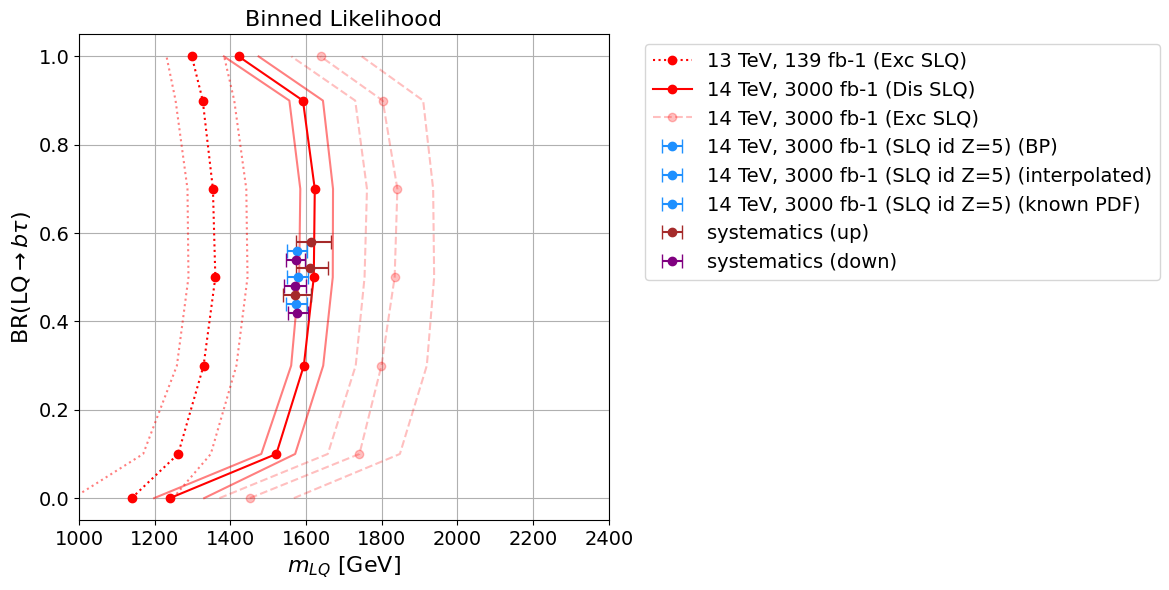

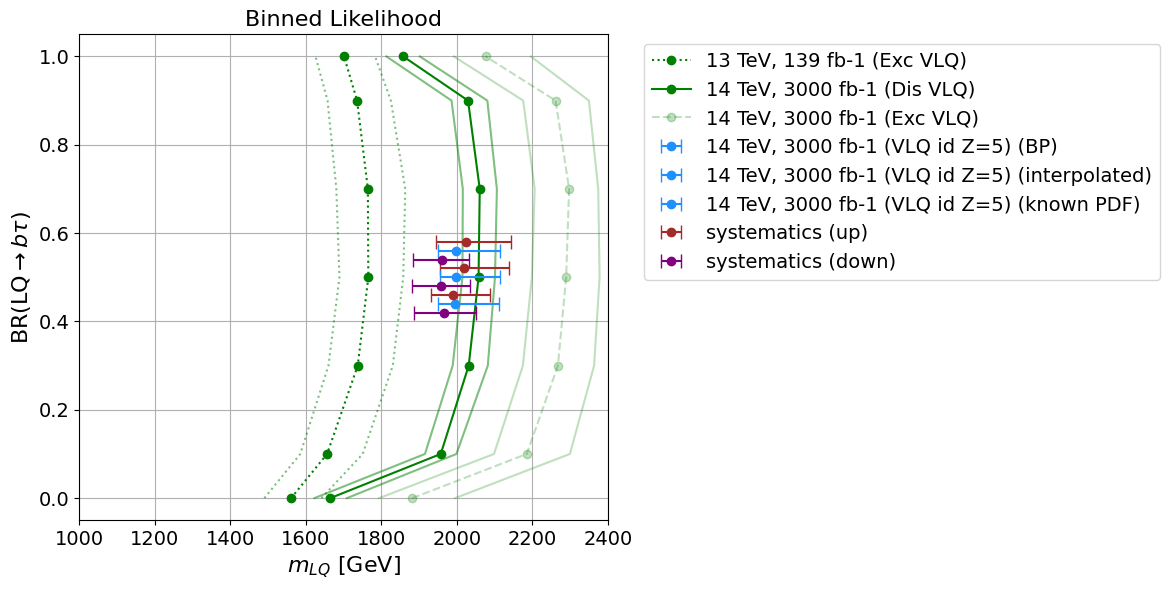

In [ ]:

# plot BINNED LIKEHOOD

plt.figure(figsize=(12, 6))

plt.plot(m_BL_exc_SLQ_13TeV, betas, 'o:', c='red', label='13 TeV, 139 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_high_13TeV, betas, ':', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_14TeV, betas, 'o-', c='red', label='14 TeV, 3000 fb-1 (Dis SLQ)')
plt.plot(m_BL_dis_SLQ_low_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_dis_SLQ_high_14TeV, betas, '-', c='red', alpha=0.5)
plt.plot(m_BL_exc_SLQ_14TeV, betas, 'o--', c='red', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc SLQ)')
plt.plot(m_BL_exc_SLQ_low_14TeV, betas, '--', c='red', alpha=0.25)
plt.plot(m_BL_exc_SLQ_high_14TeV, betas, '--', c='red', alpha=0.25)


# benchmarks
m_SLQ_T_Z5_up = [[m5_BPOK_SLQ_up - m5_BPOK_SLQ_inf_up], [m5_BPOK_SLQ_sup_up - m5_BPOK_SLQ_up]]
plt.errorbar(m5_BPOK_SLQ_up, 0.58, xerr=m_SLQ_T_Z5_up, fmt='o', capsize=5, color='brown')

m_SLQ_T_Z5 = [[m5_BPOK_SLQ - m5_BPOK_SLQ_inf], [m5_BPOK_SLQ_sup - m5_BPOK_SLQ]]
plt.errorbar(m5_BPOK_SLQ, 0.56, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (BP)')

m_SLQ_T_Z5_down = [[m5_BPOK_SLQ_down - m5_BPOK_SLQ_inf_down], [m5_BPOK_SLQ_sup_down - m5_BPOK_SLQ_down]]
plt.errorbar(m5_BPOK_SLQ_down, 0.54, xerr=m_SLQ_T_Z5_down, fmt='o', capsize=5, color='purple')

# interpolated
m_SLQ_T_Z5_up = [[m5_inter_SLQ_up - m5_inter_SLQ_inf_up], [m5_inter_SLQ_sup_up - m5_inter_SLQ_up]]
plt.errorbar(m5_inter_SLQ_up, 0.52, xerr=m_SLQ_T_Z5_up, fmt='o', capsize=5, color='brown')

m_SLQ_T_Z5 = [[m5_inter_SLQ - m5_inter_SLQ_inf], [m5_inter_SLQ_sup - m5_inter_SLQ]]
plt.errorbar(m5_inter_SLQ, 0.5, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (interpolated)')

m_SLQ_T_Z5_down = [[m5_inter_SLQ_down - m5_inter_SLQ_inf_down], [m5_inter_SLQ_sup_down - m5_inter_SLQ_down]]
plt.errorbar(m5_inter_SLQ_down, 0.48, xerr=m_SLQ_T_Z5_down, fmt='o', capsize=5, color='purple')

# known pdf

m_SLQ_T_Z5 = [[m5_prev_SLQ - m5_prev_SLQ_inf], [m5_prev_SLQ_sup - m5_prev_SLQ]]
plt.errorbar(m5_prev_SLQ, 0.44, xerr=m_SLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (SLQ id Z=5) (known PDF)')

m_SLQ_T_Z5_up = [[m5_prev_SLQ_up - m5_prev_SLQ_inf_up], [m5_prev_SLQ_sup_up - m5_prev_SLQ_up]]
plt.errorbar(m5_prev_SLQ_up, 0.46, xerr=m_SLQ_T_Z5_up, fmt='o', capsize=5, color='brown', label='systematics (up)')

m_SLQ_T_Z5_down = [[m5_prev_SLQ_down - m5_prev_SLQ_inf_down], [m5_prev_SLQ_sup_down - m5_prev_SLQ_down]]
plt.errorbar(m5_prev_SLQ_down, 0.42, xerr=m_SLQ_T_Z5_down, fmt='o', capsize=5, color='purple', label='systematics (down)')


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()





plt.figure(figsize=(12, 6))

plt.plot(m_BL_exc_VLQ_13TeV, betas, 'o:', c='green', label='13 TeV, 139 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_high_13TeV, betas, ':', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_14TeV, betas, 'o-', c='green', label='14 TeV, 3000 fb-1 (Dis VLQ)')
plt.plot(m_BL_dis_VLQ_low_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_dis_VLQ_high_14TeV, betas, '-', c='green', alpha=0.5)
plt.plot(m_BL_exc_VLQ_14TeV, betas, 'o--', c='green', alpha=0.25, label='14 TeV, 3000 fb-1 (Exc VLQ)')
plt.plot(m_BL_exc_VLQ_low_14TeV, betas, '-', c='green', alpha=0.25)
plt.plot(m_BL_exc_VLQ_high_14TeV, betas, '-', c='green', alpha=0.25)


# benchmarks
m_VLQ_T_Z5_up = [[m5_BPOK_VLQ_up - m5_BPOK_VLQ_inf_up], [m5_BPOK_VLQ_sup_up - m5_BPOK_VLQ_up]]
plt.errorbar(m5_BPOK_VLQ_up, 0.58, xerr=m_VLQ_T_Z5_up, fmt='o', capsize=5, color='brown')

m_VLQ_T_Z5 = [[m5_BPOK_VLQ - m5_BPOK_VLQ_inf], [m5_BPOK_VLQ_sup - m5_BPOK_VLQ]]
plt.errorbar(m5_BPOK_VLQ, 0.56, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (BP)')

m_VLQ_T_Z5_down = [[m5_BPOK_VLQ_down - m5_BPOK_VLQ_inf_down], [m5_BPOK_VLQ_sup_down - m5_BPOK_VLQ_down]]
plt.errorbar(m5_BPOK_VLQ_down, 0.54, xerr=m_VLQ_T_Z5_down, fmt='o', capsize=5, color='purple')

# interpolated
m_VLQ_T_Z5_up = [[m5_inter_VLQ_up - m5_inter_VLQ_inf_up], [m5_inter_VLQ_sup_up - m5_inter_VLQ_up]]
plt.errorbar(m5_inter_VLQ_up, 0.52, xerr=m_VLQ_T_Z5_up, fmt='o', capsize=5, color='brown')

m_VLQ_T_Z5 = [[m5_inter_VLQ - m5_inter_VLQ_inf], [m5_inter_VLQ_sup - m5_inter_VLQ]]
plt.errorbar(m5_inter_VLQ, 0.5, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (interpolated)')

m_VLQ_T_Z5_down = [[m5_inter_VLQ_down - m5_inter_VLQ_inf_down], [m5_inter_VLQ_sup_down - m5_inter_VLQ_down]]
plt.errorbar(m5_inter_VLQ_down, 0.48, xerr=m_VLQ_T_Z5_down, fmt='o', capsize=5, color='purple')

# knwon pdf

m_VLQ_T_Z5 = [[m5_prev_VLQ - m5_prev_VLQ_inf], [m5_prev_VLQ_sup - m5_prev_VLQ]]
plt.errorbar(m5_prev_VLQ, 0.44, xerr=m_VLQ_T_Z5, fmt='o', capsize=5, color='dodgerblue', label='14 TeV, 3000 fb-1 (VLQ id Z=5) (known PDF)')

m_VLQ_T_Z5_up = [[m5_prev_VLQ_up - m5_prev_VLQ_inf_up], [m5_prev_VLQ_sup_up - m5_prev_VLQ_up]]
plt.errorbar(m5_prev_VLQ_up, 0.46, xerr=m_VLQ_T_Z5_up, fmt='o', capsize=5, color='brown', label='systematics (up)')

m_VLQ_T_Z5_down = [[m5_prev_VLQ_down - m5_prev_VLQ_inf_down], [m5_prev_VLQ_sup_down - m5_prev_VLQ_down]]
plt.errorbar(m5_prev_VLQ_down, 0.42, xerr=m_VLQ_T_Z5_down, fmt='o', capsize=5, color='purple', label='systematics (down)')


# plt.axhline(y=5, linestyle='--', color='black')
# plt.axhline(y=2, linestyle=':', color='black')
plt.xlim(1000,2400)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r"$m_{LQ}$ [GeV]",fontsize=16)
plt.ylabel(r"BR(LQ$\rightarrow b \tau$)",fontsize=16)
plt.title('Binned Likelihood', fontsize=16)
plt.grid(True)
plt.legend(fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()